In [1]:

# %% [markdown]
# # Plot Mimicry Summary — Interactive Debug Version
# Run each cell independently. Adjust paths and MHC_CLASS in the config cell below.

# %% Cell 1: Imports
import re
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from scipy.stats import binom, fisher_exact
from statsmodels.stats.multitest import multipletests
from collections import Counter

In [32]:
#%% Cell 2: Configuration (edit these instead of CLI args)
MHC_CLASS = "I"  # "I" or "II"
INPUT_FILE = "/ix/djishnu/Priyamvada/virauto/results/netmhcpan/iedb/mhc_i/swissprot/parsed/iedb_mhci_strong_mimicry.csv.gz"
BLAST_INPUT_FILE = "/ix/djishnu/Priyamvada/virauto/data/epitopes/iedb/blast/mhc_i/iedb_mhci_pairs_4digit_hla_swissprot.csv.gz"
PAIR_ID_MAP_FILE = "/ix/djishnu/Priyamvada/virauto/data/epitopes/iedb/netmhcpan/mhc_i/swissprot/pair_id_mapping.csv.gz"
HLA_RISK_FILE = "/ix/djishnu/Priyamvada/pepSource/data/Ogishi_biorxiv_2019/HLA_autoimmunity_classification_standard.tsv"
IEDB_FASTA_FILE = "/ix/djishnu/Priyamvada/virauto/data/epitopes/iedb/fasta/iedb_epitopes_mhc_i.fasta"
FIG_DIR = "/ix/djishnu/Priyamvada/virauto/results/mimicry_analysis/iedb/mhc_i/swissprot/summary_figures_test"
RISK_CLASS_KEY = "ClassI" if MHC_CLASS == "I" else "ClassII"
os.makedirs(FIG_DIR, exist_ok=True)
print(f"=== MHC Class {MHC_CLASS} ===")

=== MHC Class I ===


In [6]:
# %% Cell 3: Plot style
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
})

In [35]:
# %% Cell 4: Helper functions
def binomial_enrichment_test(k_values, n_values, global_rate):
    pvals = []
    for k, n in zip(k_values, n_values):
        if n == 0:
            pvals.append(1.0)
        else:
            pval = 1.0 - binom.cdf(k - 1, n, global_rate)
            pvals.append(min(pval, 1.0))
    pvals = np.array(pvals)
    if len(pvals) > 0 and (pvals < 1.0).any():
        _, qvals, _, _ = multipletests(pvals, method="fdr_bh")
    else:
        qvals = pvals.copy()
    return pvals, qvals


def qval_to_stars(q):
    if q < 0.001:
        return "***"
    elif q < 0.01:
        return "**"
    elif q < 0.05:
        return "*"
    return ""


def netmhciipan_to_standard(allele):
    """Convert NetMHCIIpan allele format to standard nomenclature."""
    if "*" in allele and ":" in allele:
        return allele
    m = re.match(r"HLA-(D[QP]A1)(\d{4})-(D[QP]B1)(\d{4})$", allele)
    if m:
        a_gene, a_digits, b_gene, b_digits = m.groups()
        return (f"HLA-{a_gene}*{a_digits[:2]}:{a_digits[2:]}/"
                f"{b_gene}*{b_digits[:2]}:{b_digits[2:]}")
    m = re.match(r"(DRB[1345]|DPA1|DPB1|DQA1|DQB1)_(\d{4})$", allele)
    if m:
        gene, digits = m.groups()
        return f"HLA-{gene}*{digits[:2]}:{digits[2:]}"
    return allele


def load_hla_risk(filepath, class_key):
    """Load HLA risk annotations, filtered to the specified MHC class."""
    risk_df = pd.read_csv(filepath, sep="\t")
    risk_cls = risk_df[risk_df["HLA_Class"] == class_key].copy()
    return risk_cls


def allele_matches_hla(allele, hla_set):
    """Check if an allele (possibly NetMHCIIpan format) matches any HLA in a set.
    
    Handles exact match on standard form and substring match for paired alleles.
    """
    std = netmhciipan_to_standard(allele)
    if std in hla_set:
        return True
    for h in hla_set:
        short = h.replace("HLA-", "")
        if short in std:
            return True
    return False


def get_disease_allele_sets(risk_cls):
    """Build per-disease sets of predisposing and protective alleles.
    
    Returns:
        disease_pred: dict {disease: set of HLA alleles that are predisposing}
        disease_prot: dict {disease: set of HLA alleles that are protective}
    """
    disease_pred = {}
    disease_prot = {}
    for _, row in risk_cls.iterrows():
        d = row["Disease"]
        h = row["HLA"]
        if row["Association"] == "Predisposing":
            disease_pred.setdefault(d, set()).add(h)
        elif row["Association"] == "Protective":
            disease_prot.setdefault(d, set()).add(h)
    return disease_pred, disease_prot

In [28]:
# %% Cell 5: Load strong mimicry candidates
print("Loading strong mimicry candidates...")
df = pd.read_csv(INPUT_FILE, low_memory=False)
print(f"  Total records: {len(df):,}")
print(f"  Unique pair_ids: {df['pair_id'].nunique():,}")
print(f"  Unique viral peptides: {df['viral_peptide'].nunique():,}")
print(f"  Unique human peptides: {df['human_peptide'].nunique():,}")

df["source_organism_short"] = (
    df["source_organism"]
    .str.replace(r"\s*\(.*?\)", "", regex=True)
    .str.strip()
)
df["hla_locus"] = df["mhc_allele"].str.extract(r"(HLA-[ABC])")
df.head()

Loading strong mimicry candidates...
  Total records: 6,639
  Unique pair_ids: 6,639
  Unique viral peptides: 3,737
  Unique human peptides: 5,420


,pair_id,allele_file,viral_peptide,viral_rank_BA,viral_rank_EL,viral_score_BA,viral_score_EL,viral_NB,viral_peptide_len,human_peptide,...,send,hu_prot_name,source_organism,mhc_allele,n_mismatches,pident,coverage,qlen,source_organism_short,hla_locus
0,AGGH,HLA_C_12_02,KEPVHGVY,0.0,11.600049,0.068018,0.001768,0,8,LPEPVHGVAF,...,1257,WDR90_HUMAN,Lentivirus humimdef1,HLA-C*12:02,3,70.000,0.909091,11,Lentivirus humimdef1,HLA-C
1,ACC4,HLA_C_12_02,YQSGLSIVM,0.0,0.190298,0.644547,0.414443,1,9,YQSGFSLVM,...,248,FMNL1_HUMAN,Mycobacterium tuberculosis,HLA-C*12:02,2,77.778,1.000000,9,Mycobacterium tuberculosis,HLA-C
2,AGAZ,HLA_C_08_01,GPLLVLQA,0.0,41.984100,0.016227,0.000008,0,8,LIGPLLICQ,...,1752,FA5_HUMAN,Orthohepadnavirus hominoidei,HLA-C*08:01,3,66.667,0.900000,10,Orthohepadnavirus hominoidei,HLA-C
3,AEY8,HLA_C_08_02,LQHYREVAA,0.0,14.177195,0.058000,0.000569,0,9,LQHYAKIA,...,731,HS105_HUMAN,Human herpesvirus 4 (Epstein Barr virus),HLA-C*08:02,3,66.667,1.000000,9,Human herpesvirus 4,HLA-C
4,AALC,HLA_A_01_01,SEERPPTPY,0.0,1.213645,0.098938,0.112540,1,9,EREERPPT,...,81,AKIP1_HUMAN,Human herpesvirus 4 (Epstein Barr virus),HLA-A*01:01,1,87.500,0.800000,10,Human herpesvirus 4,HLA-A


In [29]:
#  %% Cell 6: Load IEDB epitope FASTA (organism denominator)
print("Loading IEDB epitope FASTA (pre-BLAST)...")
fasta_org_per_sid = {}
with open(IEDB_FASTA_FILE) as fh:
    for line in fh:
        if not line.startswith(">"):
            continue
        parts = line[1:].strip().split("|")
        if len(parts) >= 3:
            sid = parts[0]
            org = parts[2].replace("_", " ")
            fasta_org_per_sid[sid] = org

print(f"  Total unique structure_ids: {len(fasta_org_per_sid):,}")

org_sid_counts = Counter()
for sid, org in fasta_org_per_sid.items():
    org_sid_counts[org] += 1
epitopes_per_org_fasta = pd.Series(org_sid_counts, name="fasta_epitopes")
print(f"  Unique organisms: {len(epitopes_per_org_fasta)}")

org_short_map_fasta = {
    org: pd.Series([org]).str.replace(r"\s*\(.*?\)", "", regex=True).str.strip().iloc[0]
    for org in epitopes_per_org_fasta.index
}

Loading IEDB epitope FASTA (pre-BLAST)...
  Total unique structure_ids: 7,744
  Unique organisms: 255


In [30]:
# %% Cell 7: Load BLAST input + pair IDs (HLA denominator)
print("Loading BLAST input file + pair IDs...")
blast_df = pd.read_csv(BLAST_INPUT_FILE, low_memory=False)
pair_map = pd.read_csv(PAIR_ID_MAP_FILE, low_memory=False)

blast_df["pair_key"] = (
    blast_df["structure_id"].astype(str) + "_" +
    blast_df["hu_prot_id"].astype(str) + "_" +
    blast_df["viral_sequence"].astype(str) + "_" +
    blast_df["human_mimic_sequence"].astype(str)
)
key_to_pair_id = pair_map.drop_duplicates("pair_key").set_index("pair_key")["pair_id"]
blast_df["pair_id"] = blast_df["pair_key"].map(key_to_pair_id)
blast_df = blast_df.dropna(subset=["pair_id"])
print(f"  BLAST pairs with pair_id: {len(blast_df):,}")

pairs_per_hla_input = (
    blast_df.groupby("mhc_allele")["pair_id"].nunique().rename("input_pairs")
)
print(f"  HLA alleles in input: {len(pairs_per_hla_input)}")


Loading BLAST input file + pair IDs...
  BLAST pairs with pair_id: 8,270
  HLA alleles in input: 83


In [36]:
# %% Cell 8: Load HLA-autoimmunity risk annotations
print("Loading HLA risk annotations...")
hla_risk_df = load_hla_risk(HLA_RISK_FILE, RISK_CLASS_KEY)
print(f"  Risk annotations loaded ({RISK_CLASS_KEY}): {len(hla_risk_df)} rows")

# Build per-disease allele sets
disease_pred, disease_prot = get_disease_allele_sets(hla_risk_df)
all_diseases = sorted(set(disease_pred.keys()) | set(disease_prot.keys()))
print(f"  Diseases with annotations: {len(all_diseases)}")
for d in all_diseases:
    n_pred = len(disease_pred.get(d, set()))
    n_prot = len(disease_prot.get(d, set()))
    print(f"    {d}: {n_pred} predisposing, {n_prot} protective")

Loading HLA risk annotations...
  Risk annotations loaded (ClassI): 72 rows
  Diseases with annotations: 8
    AS: 3 predisposing, 1 protective
    DM: 3 predisposing, 2 protective
    GD: 3 predisposing, 3 protective
    MS: 4 predisposing, 4 protective
    PSO: 5 predisposing, 2 protective
    RA: 6 predisposing, 4 protective
    SLE: 5 predisposing, 2 protective
    T1D: 12 predisposing, 13 protective


Plotting HLA allele conversion rate (Figure 1)...
  Global HLA conversion rate: 0.8097
  Significant alleles (FDR < 0.05): 5


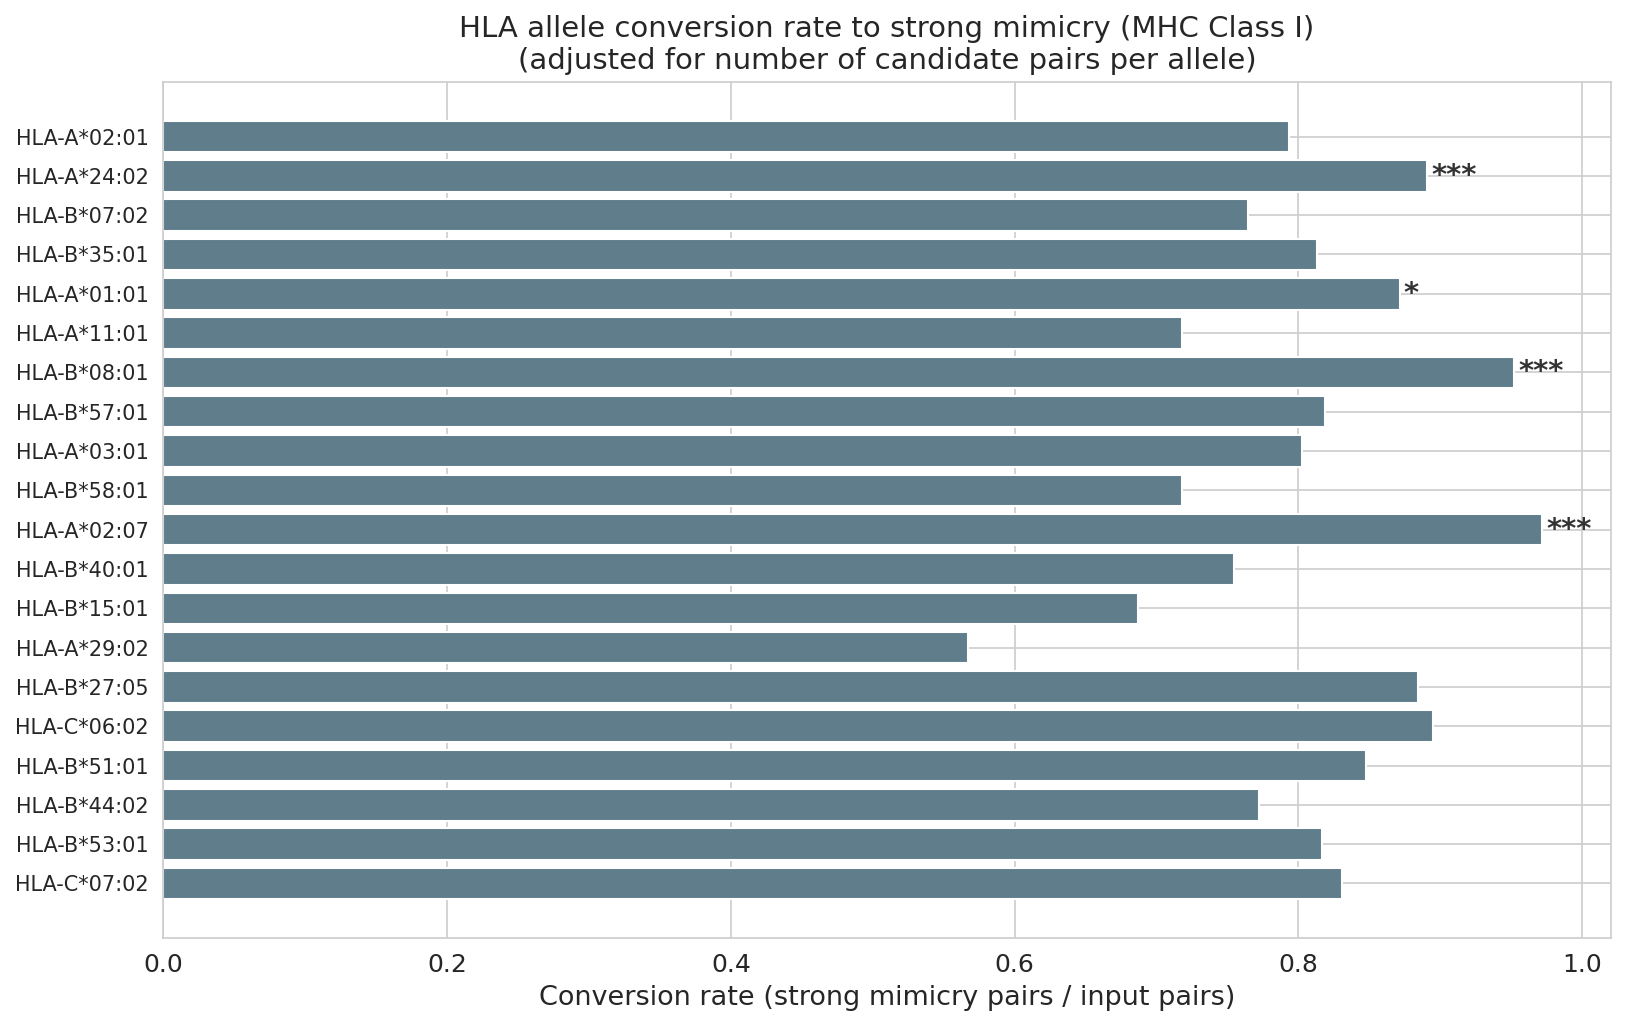

  ✅ 01_hla_conversion_rate.png


In [37]:
#  %% Cell 9: Figure 1 — HLA allele conversion rate (all alleles)
print("Plotting HLA allele conversion rate (Figure 1)...")

strong_per_hla = df.groupby("mhc_allele")["pair_id"].nunique().rename("strong_pairs")
hla_conversion = pairs_per_hla_input.to_frame().join(strong_per_hla, how="left").fillna(0)
hla_conversion["strong_pairs"] = hla_conversion["strong_pairs"].astype(int)
hla_conversion["fraction"] = hla_conversion["strong_pairs"] / hla_conversion["input_pairs"]

global_rate_hla = hla_conversion["strong_pairs"].sum() / hla_conversion["input_pairs"].sum()
print(f"  Global HLA conversion rate: {global_rate_hla:.4f}")

hla_pvals, hla_qvals = binomial_enrichment_test(
    hla_conversion["strong_pairs"].values,
    hla_conversion["input_pairs"].values,
    global_rate_hla,
)
hla_conversion["qval"] = hla_qvals
hla_conversion["stars"] = [qval_to_stars(q) for q in hla_qvals]

n_sig_hla = (hla_conversion["qval"] < 0.05).sum()
print(f"  Significant alleles (FDR < 0.05): {n_sig_hla}")

hla_conv_plot = (
    hla_conversion[hla_conversion["strong_pairs"] > 0]
    .sort_values("input_pairs", ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(11, 7))

ax.barh(range(len(hla_conv_plot)), hla_conv_plot["fraction"].values[::-1],
        color="#607D8B", edgecolor="white")
ax.set_yticks(range(len(hla_conv_plot)))
ax.set_yticklabels(hla_conv_plot.index[::-1], fontsize=10)

for i, (allele, row) in enumerate(hla_conv_plot.iloc[::-1].iterrows()):
    stars = row.get("stars", "")
    if stars:
        ax.text(row["fraction"] + 0.003, i, stars,
                va="center", fontsize=14, fontweight="bold", color="#333")

ax.set_xlabel("Conversion rate (strong mimicry pairs / input pairs)")
ax.set_title(f"HLA allele conversion rate to strong mimicry (MHC Class {MHC_CLASS})\n"
             "(adjusted for number of candidate pairs per allele)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "01_hla_conversion_rate.png"))
plt.show()
print("  ✅ 01_hla_conversion_rate.png")


Plotting disease-specific mimicry enrichment (Figure 1b)...


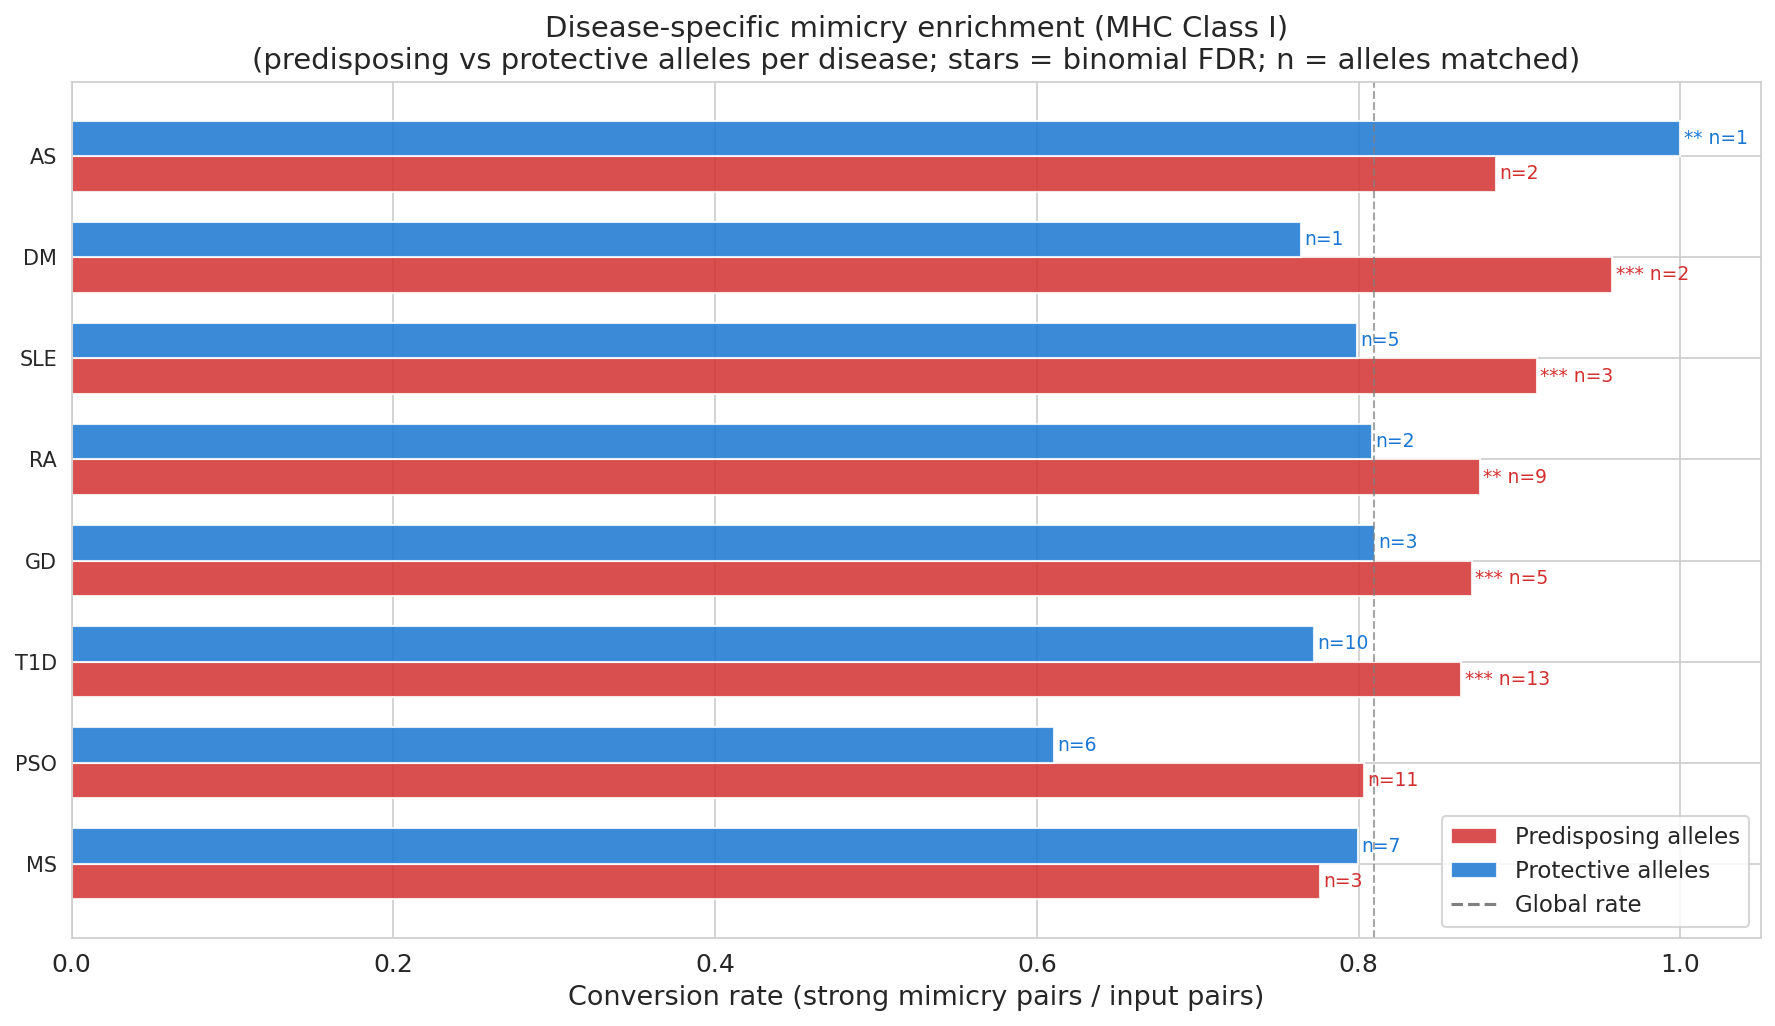

  ✅ 01b_disease_specific_enrichment.png

  Disease enrichment summary:
    AS                   Predisposing    alleles= 2  input=    96  strong=   85  rate=0.8854  q=0.0768 
    AS                   Protective      alleles= 1  input=    35  strong=   35  rate=1.0000  q=0.0017 **
    DM                   Predisposing    alleles= 2  input=   284  strong=  272  rate=0.9577  q=0.0000 ***
    DM                   Protective      alleles= 1  input=   985  strong=  753  rate=0.7645  q=1.0000 
    GD                   Predisposing    alleles= 5  input=   610  strong=  531  rate=0.8705  q=0.0002 ***
    GD                   Protective      alleles= 3  input=   121  strong=   98  rate=0.8099  q=1.0000 
    MS                   Predisposing    alleles= 3  input= 1,079  strong=  837  rate=0.7757  q=1.0000 
    MS                   Protective      alleles= 7  input= 3,235  strong=2,587  rate=0.7997  q=1.0000 
    PSO                  Predisposing    alleles=11  input= 3,388  strong=2,721  rate=0.8

In [38]:
# %% Cell 10: Figure 1b — Disease-specific mimicry enrichment
#   For each disease: aggregate conversion rate across predisposing vs protective alleles
#   Binomial test against the global rate
print("Plotting disease-specific mimicry enrichment (Figure 1b)...")

disease_rows = []

for disease in all_diseases:
    pred_hlas = disease_pred.get(disease, set())
    prot_hlas = disease_prot.get(disease, set())

    for role, hla_set in [("Predisposing", pred_hlas), ("Protective", prot_hlas)]:
        if not hla_set:
            continue

        # Find alleles in our data that match this disease-role set
        matching_alleles = [
            a for a in hla_conversion.index
            if allele_matches_hla(a, hla_set)
        ]

        if not matching_alleles:
            continue

        subset = hla_conversion.loc[matching_alleles]
        total_input = int(subset["input_pairs"].sum())
        total_strong = int(subset["strong_pairs"].sum())

        if total_input == 0:
            continue

        frac = total_strong / total_input

        # Binomial test against global rate
        if total_strong > 0:
            pval = 1.0 - binom.cdf(total_strong - 1, total_input, global_rate_hla)
        else:
            pval = 1.0

        disease_rows.append({
            "disease": disease,
            "role": role,
            "n_alleles": len(matching_alleles),
            "input_pairs": total_input,
            "strong_pairs": total_strong,
            "fraction": frac,
            "pval": pval,
        })

disease_enrich = pd.DataFrame(disease_rows)

if not disease_enrich.empty:
    # FDR correction across all tests
    _, qvals, _, _ = multipletests(disease_enrich["pval"].values, method="fdr_bh")
    disease_enrich["qval"] = qvals
    disease_enrich["stars"] = [qval_to_stars(q) for q in qvals]

    # Sort diseases by max conversion rate for display
    disease_max_frac = disease_enrich.groupby("disease")["fraction"].max().sort_values(ascending=False)
    disease_order = disease_max_frac.index.tolist()

    # Build paired bar chart
    fig, ax = plt.subplots(figsize=(12, max(7, len(disease_order) * 0.6)))

    bar_height = 0.35
    y_positions = np.arange(len(disease_order))

    pred_data = disease_enrich[disease_enrich["role"] == "Predisposing"].set_index("disease")
    prot_data = disease_enrich[disease_enrich["role"] == "Protective"].set_index("disease")

    for i, disease in enumerate(disease_order):
        # Predisposing bar
        if disease in pred_data.index:
            row = pred_data.loc[disease]
            ax.barh(i + bar_height / 2, row["fraction"], height=bar_height,
                    color="#D32F2F", alpha=0.85, edgecolor="white")
            label = f'n={row["n_alleles"]}'
            stars = row.get("stars", "")
            if stars:
                label = f"{stars} {label}"
            ax.text(row["fraction"] + 0.002, i + bar_height / 2, label,
                    va="center", fontsize=9, color="#D32F2F")

        # Protective bar
        if disease in prot_data.index:
            row = prot_data.loc[disease]
            ax.barh(i - bar_height / 2, row["fraction"], height=bar_height,
                    color="#1976D2", alpha=0.85, edgecolor="white")
            label = f'n={row["n_alleles"]}'
            stars = row.get("stars", "")
            if stars:
                label = f"{stars} {label}"
            ax.text(row["fraction"] + 0.002, i - bar_height / 2, label,
                    va="center", fontsize=9, color="#1976D2")

    # Global rate reference line
    ax.axvline(global_rate_hla, color="gray", linestyle="--", linewidth=1,
               alpha=0.7, label=f"Global rate ({global_rate_hla:.4f})")

    ax.set_yticks(y_positions)
    ax.set_yticklabels(disease_order, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel("Conversion rate (strong mimicry pairs / input pairs)")
    ax.set_title(f"Disease-specific mimicry enrichment (MHC Class {MHC_CLASS})\n"
                 "(predisposing vs protective alleles per disease; "
                 "stars = binomial FDR; n = alleles matched)")

    legend_elements = [
        Patch(facecolor="#D32F2F", alpha=0.85, label="Predisposing alleles"),
        Patch(facecolor="#1976D2", alpha=0.85, label="Protective alleles"),
        plt.Line2D([0], [0], color="gray", linestyle="--", label="Global rate"),
    ]
    ax.legend(handles=legend_elements, fontsize=11, loc="lower right")

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "01b_disease_specific_enrichment.png"))
    plt.show()
    print("  ✅ 01b_disease_specific_enrichment.png")

    # Print table
    print("\n  Disease enrichment summary:")
    for _, row in disease_enrich.sort_values(["disease", "role"]).iterrows():
        print(f"    {row['disease']:20s} {row['role']:14s}  "
              f"alleles={row['n_alleles']:2d}  "
              f"input={row['input_pairs']:6,d}  "
              f"strong={row['strong_pairs']:5,d}  "
              f"rate={row['fraction']:.4f}  "
              f"q={row['qval']:.4f} {row['stars']}")
else:
    print("  ⚠️  No disease-allele combinations found in data — skipping 1b")

Plotting source organism conversion rate (Figure 2)...
  Global organism conversion rate: 0.3285
  Significant organisms (FDR < 0.05): 4


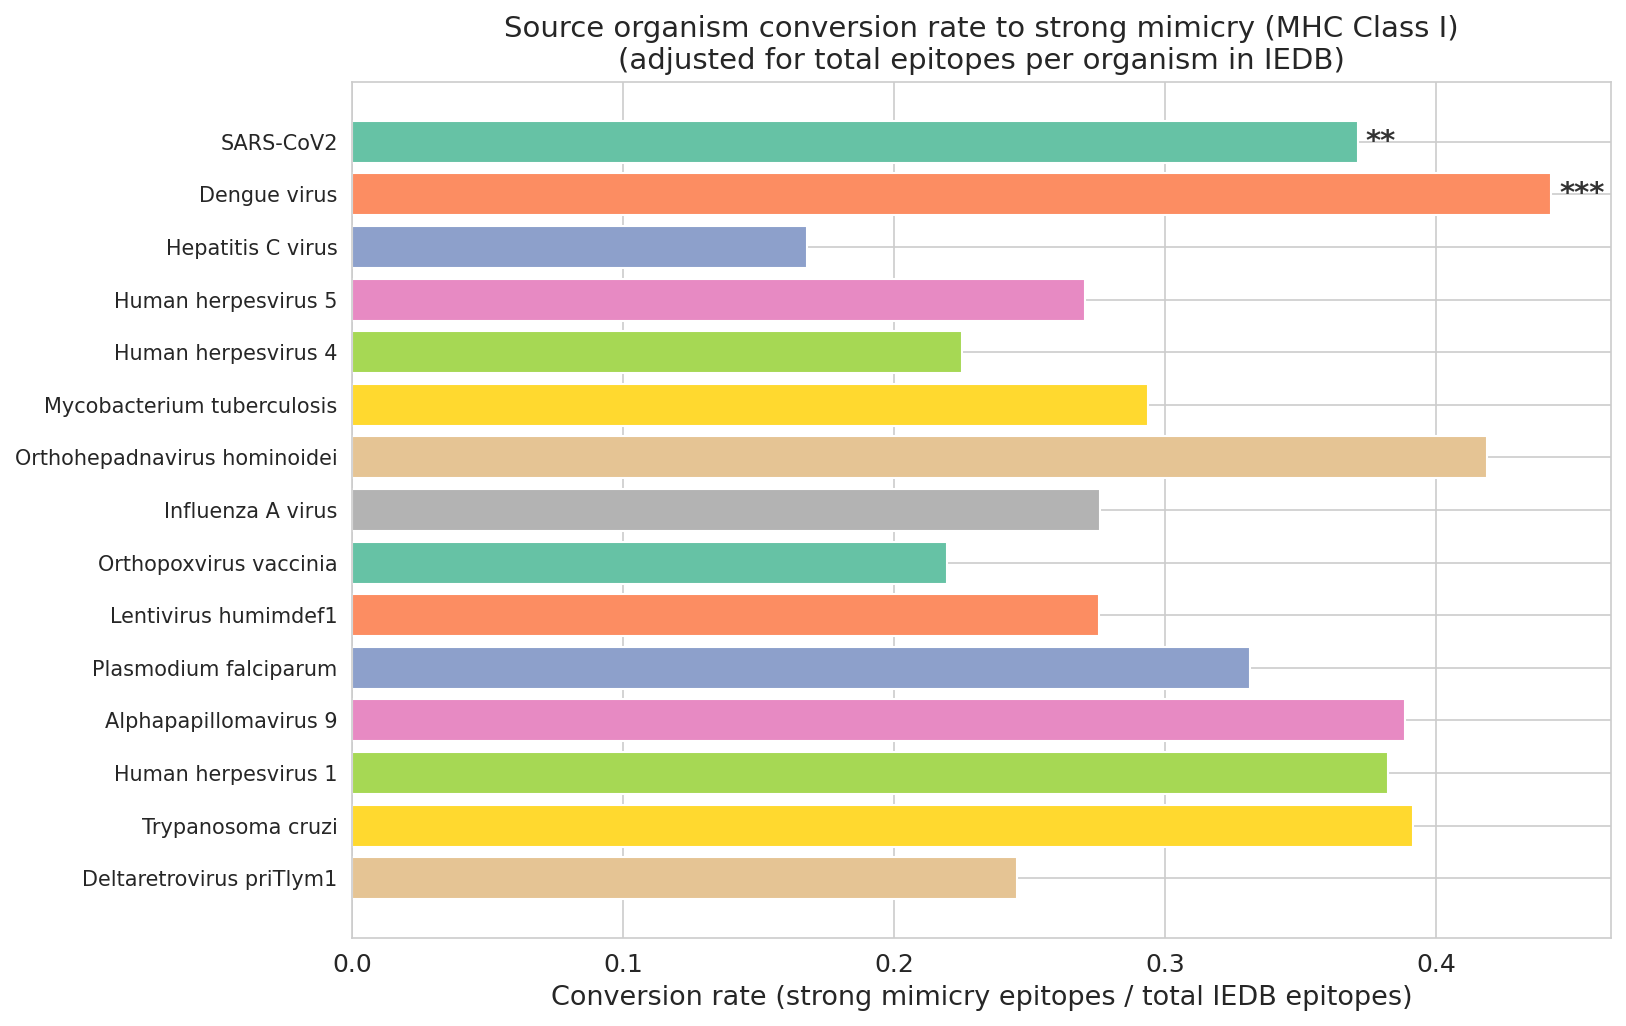

  ✅ 02_organism_conversion_rate.png


In [39]:
# %% Cell 11: Figure 2 — Source organism conversion rate
print("Plotting source organism conversion rate (Figure 2)...")

strong_epi_per_org = df.groupby("source_organism")["structure_id"].nunique().rename("strong_epitopes")
org_conversion = epitopes_per_org_fasta.to_frame().join(strong_epi_per_org, how="left").fillna(0)
org_conversion["strong_epitopes"] = org_conversion["strong_epitopes"].astype(int)
org_conversion["fraction"] = org_conversion["strong_epitopes"] / org_conversion["fasta_epitopes"]

global_rate_org = org_conversion["strong_epitopes"].sum() / org_conversion["fasta_epitopes"].sum()
print(f"  Global organism conversion rate: {global_rate_org:.4f}")

org_pvals, org_qvals = binomial_enrichment_test(
    org_conversion["strong_epitopes"].values,
    org_conversion["fasta_epitopes"].values,
    global_rate_org,
)
org_conversion["qval"] = org_qvals
org_conversion["stars"] = [qval_to_stars(q) for q in org_qvals]

n_sig_org = (org_conversion["qval"] < 0.05).sum()
print(f"  Significant organisms (FDR < 0.05): {n_sig_org}")

org_conversion["org_short"] = org_conversion.index.map(lambda x: org_short_map_fasta.get(x, x))

org_conv_plot = (
    org_conversion[org_conversion["strong_epitopes"] > 0]
    .sort_values("fasta_epitopes", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(range(len(org_conv_plot)), org_conv_plot["fraction"].values[::-1],
        color=sns.color_palette("Set2", len(org_conv_plot))[::-1], edgecolor="white")
ax.set_yticks(range(len(org_conv_plot)))
ax.set_yticklabels(org_conv_plot["org_short"].values[::-1], fontsize=10)

for i, (_, row) in enumerate(org_conv_plot.iloc[::-1].iterrows()):
    stars = row.get("stars", "")
    if stars:
        ax.text(row["fraction"] + 0.003, i, stars,
                va="center", fontsize=14, fontweight="bold", color="#333")

ax.set_xlabel("Conversion rate (strong mimicry epitopes / total IEDB epitopes)")
ax.set_title(f"Source organism conversion rate to strong mimicry (MHC Class {MHC_CLASS})\n"
             "(adjusted for total epitopes per organism in IEDB)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "02_organism_conversion_rate.png"))
plt.show()
print("  ✅ 02_organism_conversion_rate.png")

  Fisher's exact: 0 significant interactions (FDR < 0.05)


Plotting binding affinity comparison...


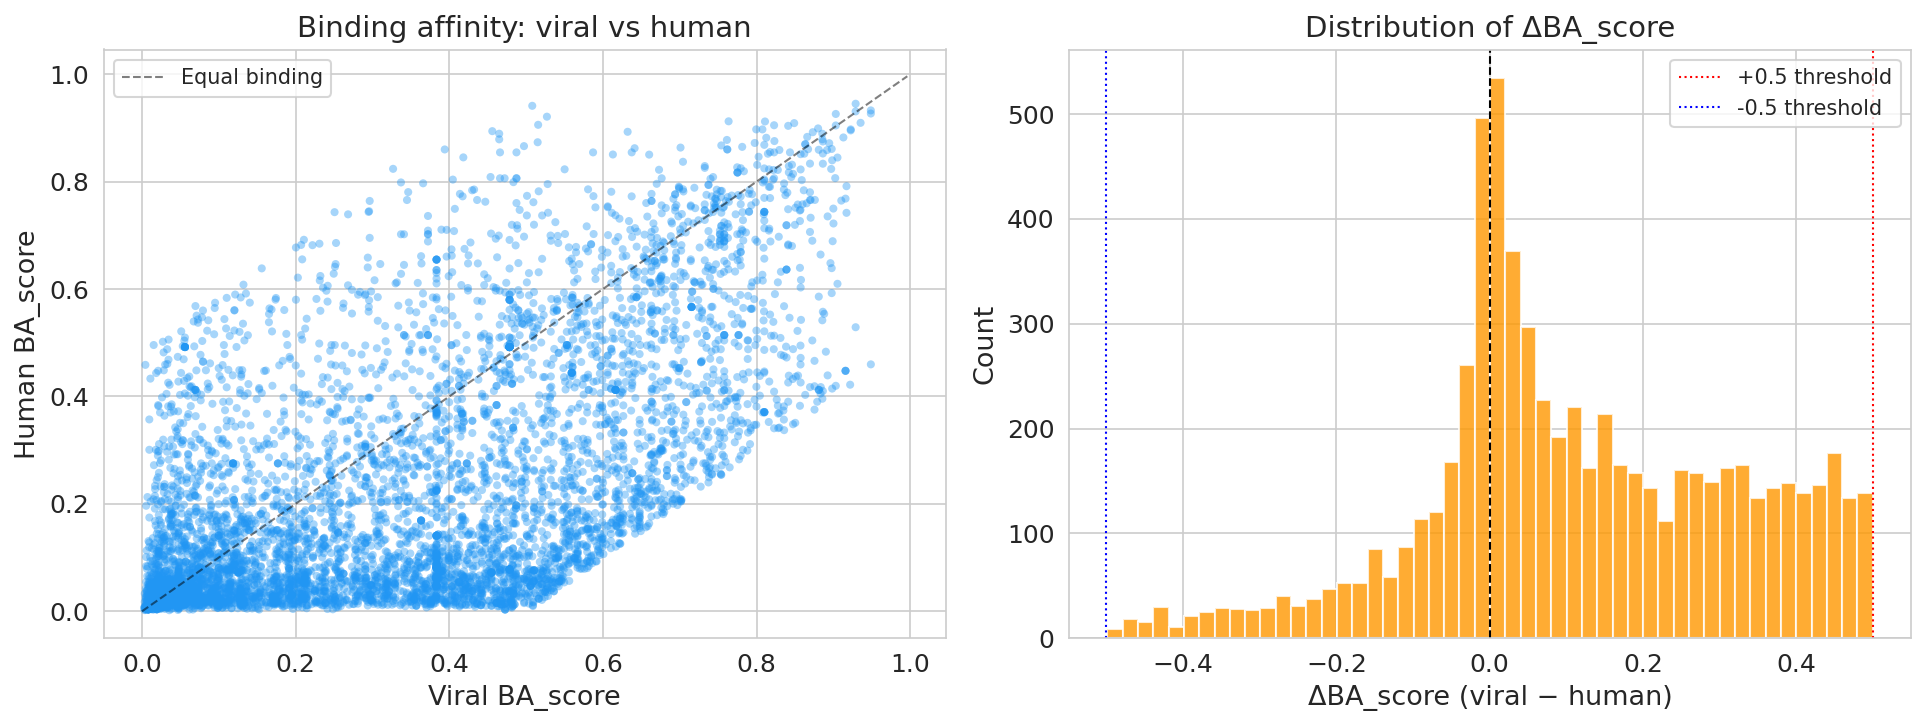

  ✅ 03_binding_comparison.png


In [40]:
# %% Cell 12: Figure 3 — Binding affinity comparison
print("Plotting binding affinity comparison...")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(df["viral_score_BA"], df["human_score_BA"],
           alpha=0.4, s=15, c="#2196F3", edgecolors="none")
lims = [0, max(df["viral_score_BA"].max(), df["human_score_BA"].max()) * 1.05]
ax.plot(lims, lims, "k--", alpha=0.5, linewidth=1, label="Equal binding")
ax.set_xlabel("Viral BA_score")
ax.set_ylabel("Human BA_score")
ax.set_title("Binding affinity: viral vs human")
ax.legend(fontsize=10)

ax = axes[1]
ax.hist(df["delta_BA_score"].dropna(), bins=50, color="#FF9800", edgecolor="white", alpha=0.8)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.axvline(0.5, color="red", linestyle=":", linewidth=1, label="+0.5 threshold")
ax.axvline(-0.5, color="blue", linestyle=":", linewidth=1, label="-0.5 threshold")
ax.set_xlabel("ΔBA_score (viral − human)")
ax.set_ylabel("Count")
ax.set_title("Distribution of ΔBA_score")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "03_binding_comparison.png"))
plt.show()
print("  ✅ 03_binding_comparison.png")


Plotting peptide properties...


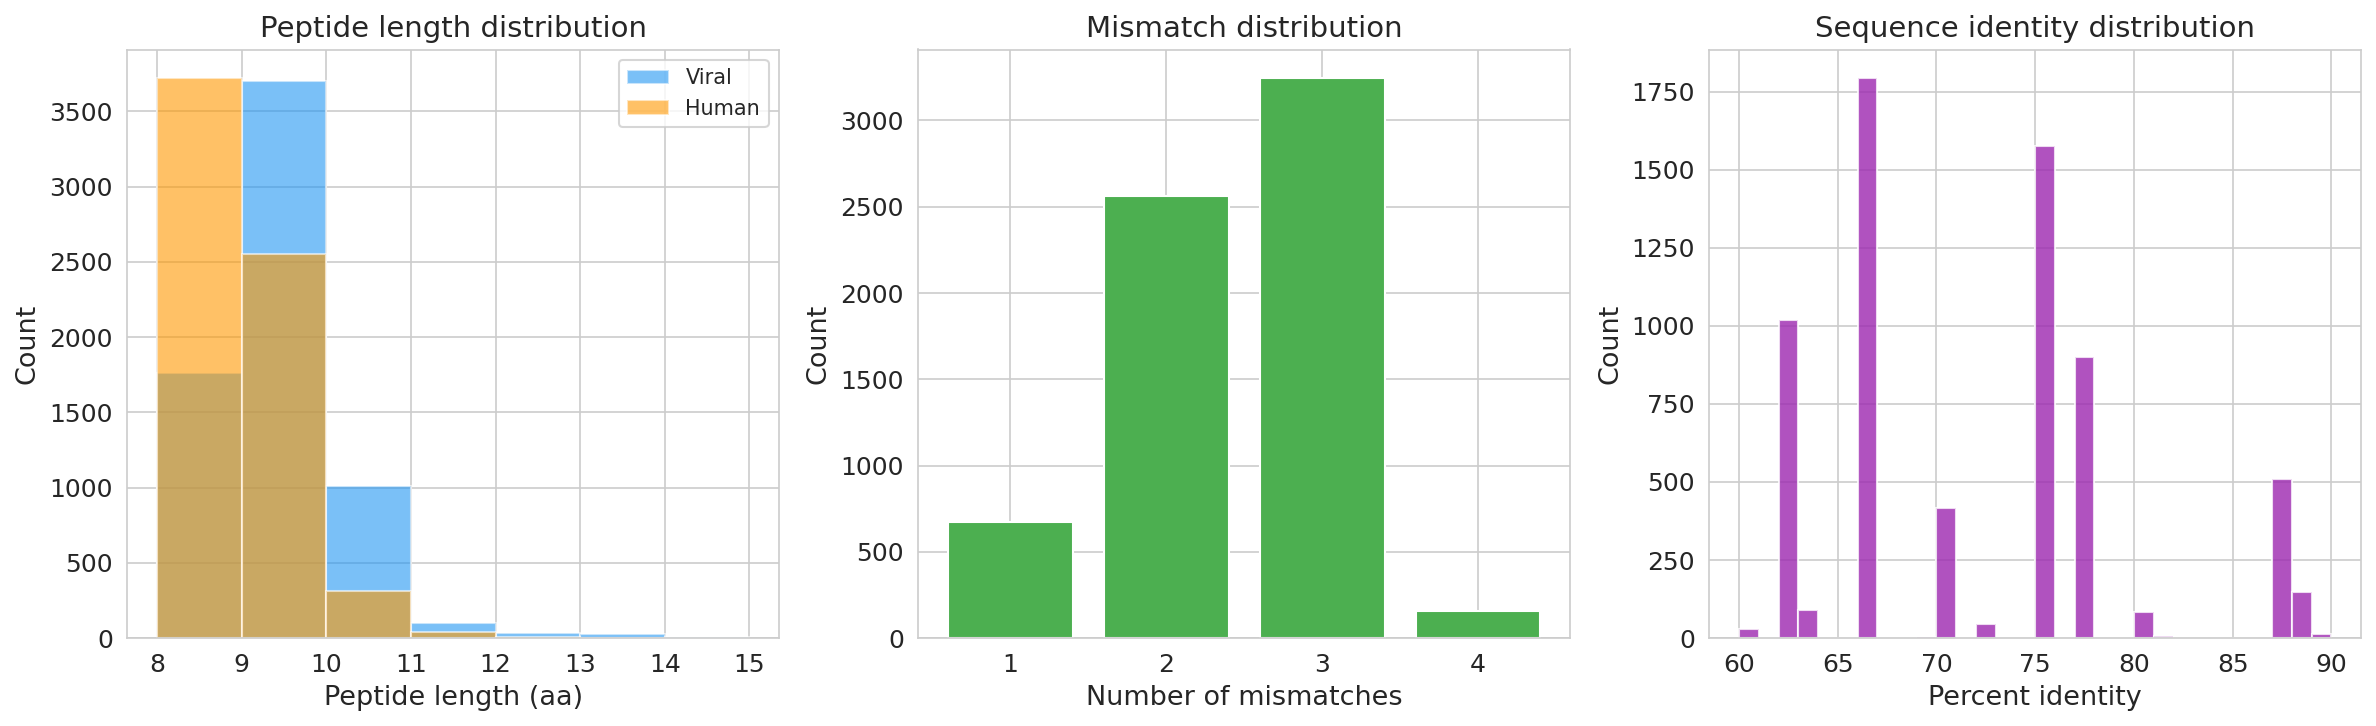

  ✅ 04_peptide_properties.png


In [42]:
# %% Cell 13: Figure 4 — Peptide length and mismatch distributions
print("Plotting peptide properties...")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
viral_lens = df["viral_peptide"].str.len()
human_lens = df["human_peptide"].str.len()
all_lens = pd.concat([viral_lens, human_lens])
bins = range(int(all_lens.min()), int(all_lens.max()) + 2)
ax.hist(viral_lens, bins=bins, alpha=0.6, label="Viral", color="#2196F3", edgecolor="white")
ax.hist(human_lens, bins=bins, alpha=0.6, label="Human", color="#FF9800", edgecolor="white")
ax.set_xlabel("Peptide length (aa)")
ax.set_ylabel("Count")
ax.set_title("Peptide length distribution")
ax.legend(fontsize=10)

ax = axes[1]
if "n_mismatches" in df.columns:
    mm_counts = df["n_mismatches"].value_counts().sort_index()
    ax.bar(mm_counts.index, mm_counts.values, color="#4CAF50", edgecolor="white")
    ax.set_xlabel("Number of mismatches")
    ax.set_ylabel("Count")
    ax.set_title("Mismatch distribution")
    ax.set_xticks(mm_counts.index)

ax = axes[2]
if "pident" in df.columns:
    ax.hist(df["pident"].dropna(), bins=30, color="#9C27B0", edgecolor="white", alpha=0.8)
    ax.set_xlabel("Percent identity")
    ax.set_ylabel("Count")
    ax.set_title("Sequence identity distribution")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "04_peptide_properties.png"))
plt.show()
print("  ✅ 04_peptide_properties.png")


In [43]:
# %% Cell 14: Prepare HLA × Organism interaction data (for Figures 5 & 5b)
print("Computing HLA × organism conversion rates and Fisher's exact tests...")

input_counts = blast_df.groupby(["mhc_allele", "source_organism"])["pair_id"].nunique().rename("input_pairs")
strong_counts = df.groupby(["mhc_allele", "source_organism"])["pair_id"].nunique().rename("strong_pairs")

conversion = input_counts.to_frame().join(strong_counts, how="left").fillna(0)
conversion["strong_pairs"] = conversion["strong_pairs"].astype(int)
conversion["fraction"] = conversion["strong_pairs"] / conversion["input_pairs"]

# Fisher's exact test
strong_per_hla_all = df.groupby("mhc_allele")["pair_id"].nunique()
strong_per_org_all = df.groupby("source_organism")["pair_id"].nunique()
total_strong_all = df["pair_id"].nunique()

cell_pvals = []
for (allele, org), row in conversion.iterrows():
    k = int(row["strong_pairs"])
    if k == 0:
        cell_pvals.append(1.0)
        continue
    a = k
    b = max(strong_per_hla_all.get(allele, 0) - a, 0)
    c = max(strong_per_org_all.get(org, 0) - a, 0)
    d = max(total_strong_all - a - b - c, 0)
    _, pval = fisher_exact([[a, b], [c, d]], alternative="greater")
    cell_pvals.append(pval)

conversion["pval_interaction"] = cell_pvals

mask_tested = conversion["strong_pairs"] > 0
conversion["qval_interaction"] = 1.0
if mask_tested.sum() > 0:
    tested_pvals = conversion.loc[mask_tested, "pval_interaction"].values
    _, tested_qvals, _, _ = multipletests(tested_pvals, method="fdr_bh")
    conversion.loc[mask_tested, "qval_interaction"] = tested_qvals

conversion["stars_interaction"] = [qval_to_stars(q) for q in conversion["qval_interaction"]]

n_sig_cells = (conversion["qval_interaction"] < 0.05).sum()
print(f"  Fisher's exact: {n_sig_cells} significant interactions (FDR < 0.05)")

# Shared lookup for dot plots
blast_df["source_organism_short"] = (
    blast_df["source_organism"].str.replace(r"\s*\(.*?\)", "", regex=True).str.strip()
)
org_short_map = (
    blast_df[["source_organism", "source_organism_short"]]
    .drop_duplicates("source_organism")
    .set_index("source_organism")["source_organism_short"]
)

top_alleles = df["mhc_allele"].value_counts().head(15).index.tolist()
top_orgs_full = df["source_organism"].value_counts().head(10).index.tolist()
top_orgs_short = [org_short_map.get(o, o) for o in top_orgs_full]

Computing HLA × organism conversion rates and Fisher's exact tests...
  Fisher's exact: 216 significant interactions (FDR < 0.05)


Plotting HLA × organism dot plot (Figure 5)...


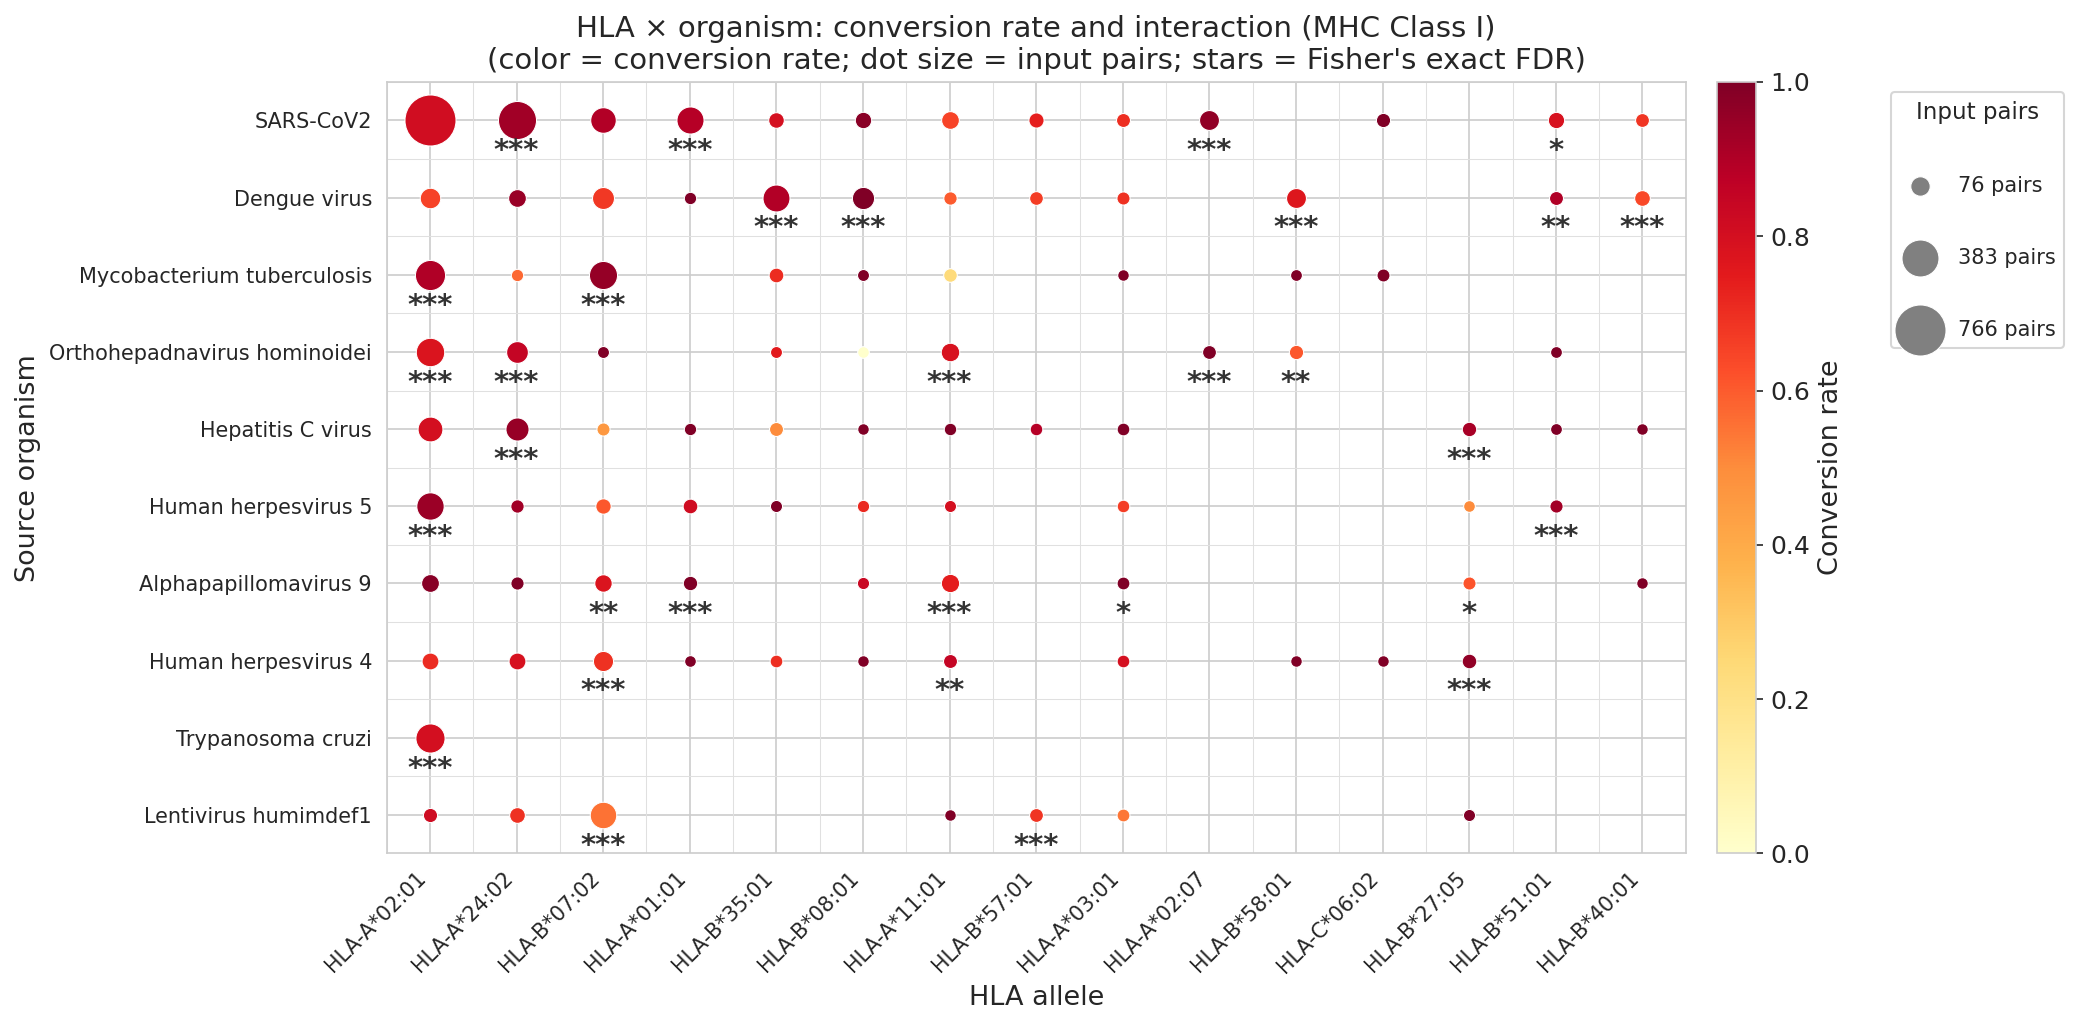

  ✅ 05_hla_organism_dotplot.png


In [44]:
# %% Cell 15: Figure 5 — HLA × Organism dot plot (all alleles)
print("Plotting HLA × organism dot plot (Figure 5)...")

min_dot, max_dot = 30, 600
cmap = plt.cm.YlOrRd

heatmap_frac = pd.DataFrame(np.nan, index=top_orgs_short, columns=top_alleles)
heatmap_input = pd.DataFrame(0, index=top_orgs_short, columns=top_alleles)
heatmap_stars = pd.DataFrame("", index=top_orgs_short, columns=top_alleles, dtype=str)

for org_full, org_short in zip(top_orgs_full, top_orgs_short):
    for allele in top_alleles:
        key = (allele, org_full)
        if key in conversion.index:
            row = conversion.loc[key]
            heatmap_frac.loc[org_short, allele] = row["fraction"]
            heatmap_input.loc[org_short, allele] = int(row["input_pairs"])
            heatmap_stars.loc[org_short, allele] = row["stars_interaction"]

heatmap_frac = heatmap_frac.fillna(0)

fig, ax = plt.subplots(figsize=(14, 7))
vmax = min(heatmap_frac.max().max() * 1.1, 1.0)
if vmax == 0:
    vmax = 0.01
norm = plt.Normalize(vmin=0, vmax=vmax)

max_input = max(heatmap_input.max().max(), 1)

for i, org_short in enumerate(top_orgs_short):
    for j, allele in enumerate(top_alleles):
        frac = heatmap_frac.loc[org_short, allele]
        n_input = heatmap_input.loc[org_short, allele]
        if n_input == 0:
            continue
        dot_size = min_dot + (n_input / max_input) * (max_dot - min_dot)
        ax.scatter(j + 0.5, i + 0.5, s=dot_size, c=[cmap(norm(frac))],
                   edgecolors="white", linewidths=0.5, zorder=3)
        stars = heatmap_stars.loc[org_short, allele]
        if stars:
            ax.text(j + 0.5, i + 0.9, stars, ha="center", va="center",
                    fontsize=14, fontweight="bold", color="#333", zorder=4)

for i in range(len(top_orgs_short) + 1):
    ax.axhline(i, color="#E0E0E0", linewidth=0.5, zorder=1)
for j in range(len(top_alleles) + 1):
    ax.axvline(j, color="#E0E0E0", linewidth=0.5, zorder=1)

ax.set_xlim(0, len(top_alleles))
ax.set_ylim(0, len(top_orgs_short))
ax.set_xticks([j + 0.5 for j in range(len(top_alleles))])
ax.set_xticklabels(top_alleles, rotation=45, ha="right", fontsize=10)
ax.set_yticks([i + 0.5 for i in range(len(top_orgs_short))])
ax.set_yticklabels(top_orgs_short, fontsize=10)
ax.invert_yaxis()

ax.set_xlabel("HLA allele")
ax.set_ylabel("Source organism")
ax.set_title(f"HLA × organism: conversion rate and interaction (MHC Class {MHC_CLASS})\n"
             "(color = conversion rate; dot size = input pairs; "
             "stars = Fisher's exact FDR)")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Conversion rate")

legend_sizes = sorted(set(max(1, s) for s in [
    int(max_input * 0.1), int(max_input * 0.5), int(max_input)
]))
legend_dots = [
    ax.scatter([], [], s=min_dot + (s / max_input) * (max_dot - min_dot),
               c="gray", edgecolors="white", linewidths=0.5, label=f"{s:,} pairs")
    for s in legend_sizes
]
ax.legend(handles=legend_dots, title="Input pairs", loc="upper left",
          bbox_to_anchor=(1.15, 1.0), labelspacing=2.5,
          fontsize=10, title_fontsize=11, frameon=True)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05_hla_organism_dotplot.png"))
plt.show()
print("  ✅ 05_hla_organism_dotplot.png")

Plotting per-disease HLA × organism dot plots (Figure 5b)...
  Diseases with alleles in data: 8


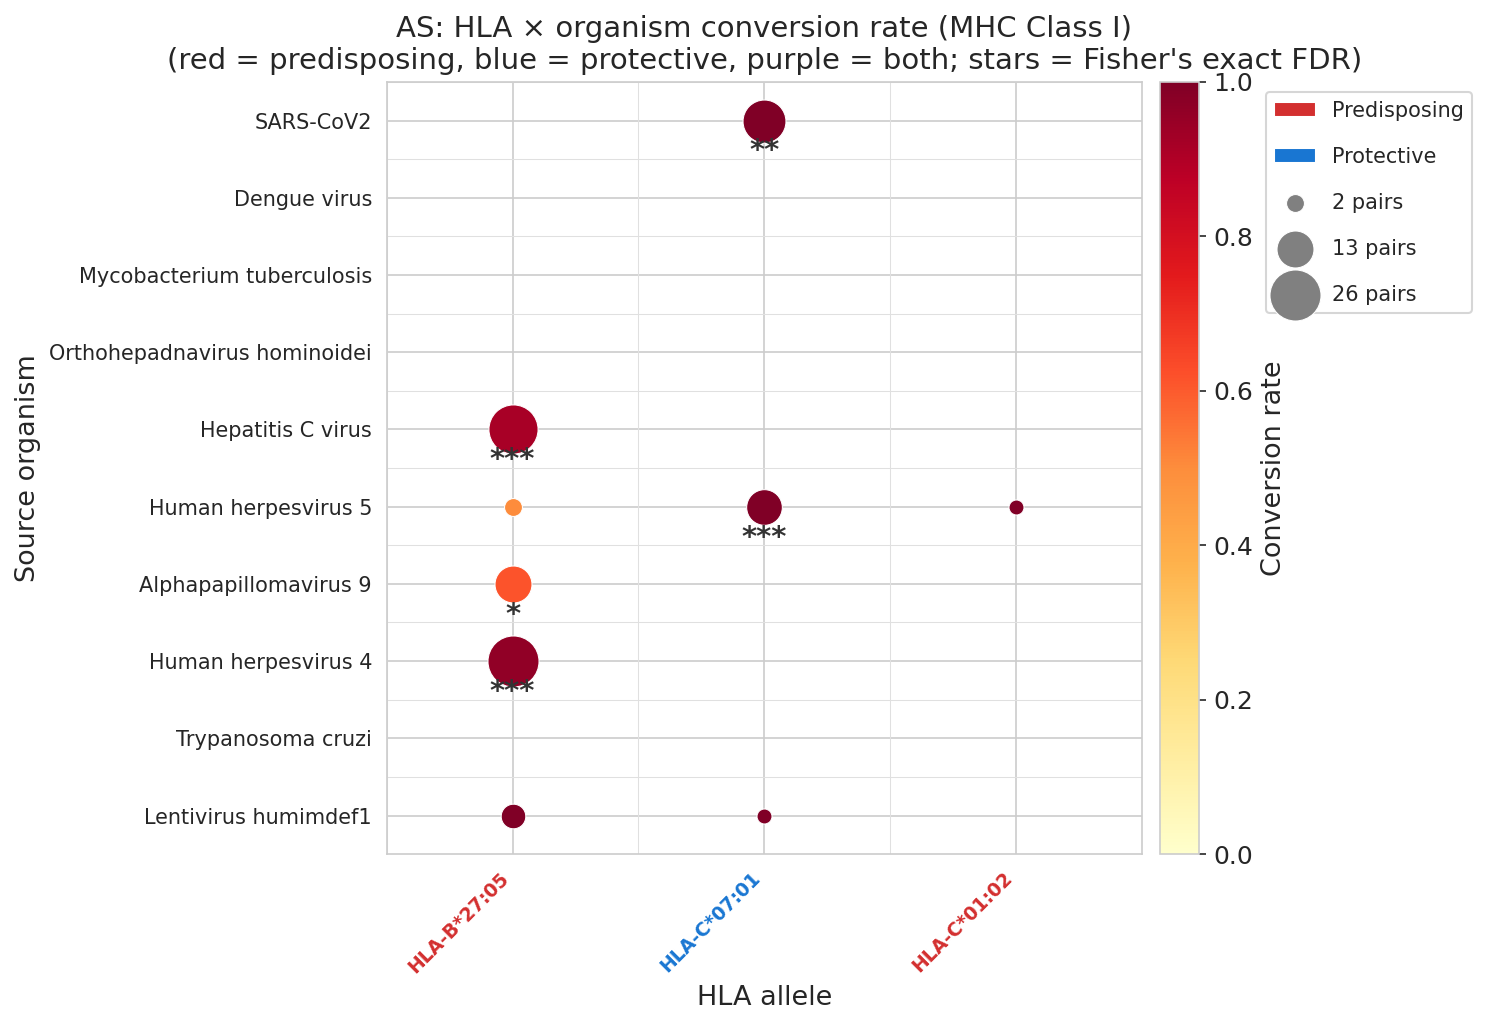

  ✅ 05b_AS_hla_organism_dotplot.png


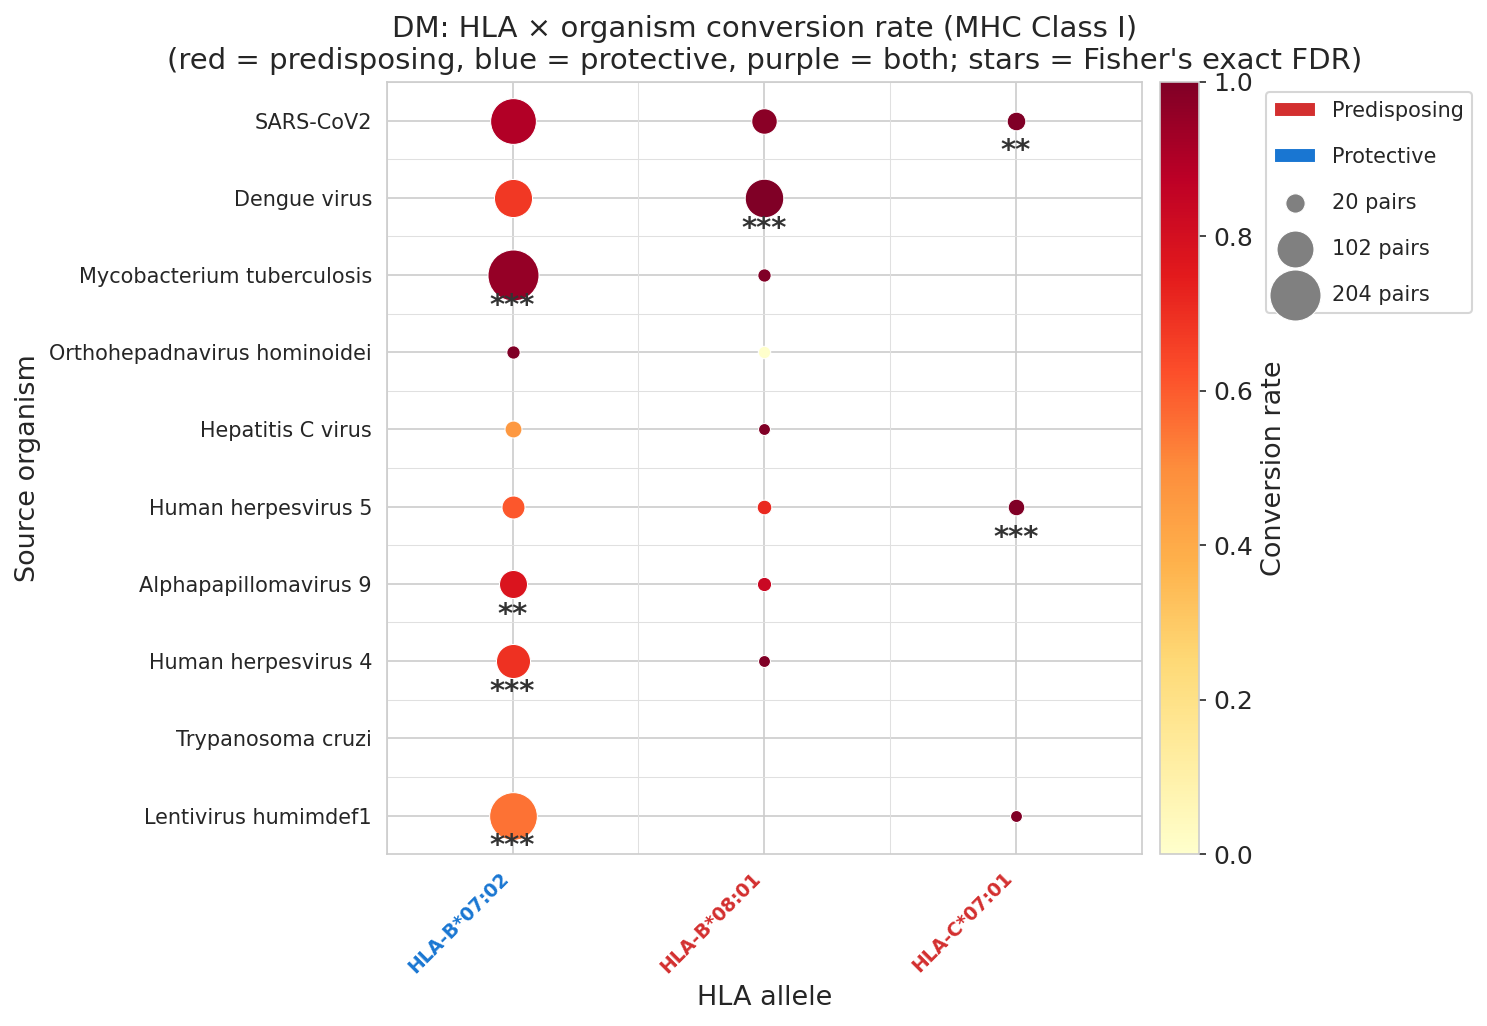

  ✅ 05b_DM_hla_organism_dotplot.png


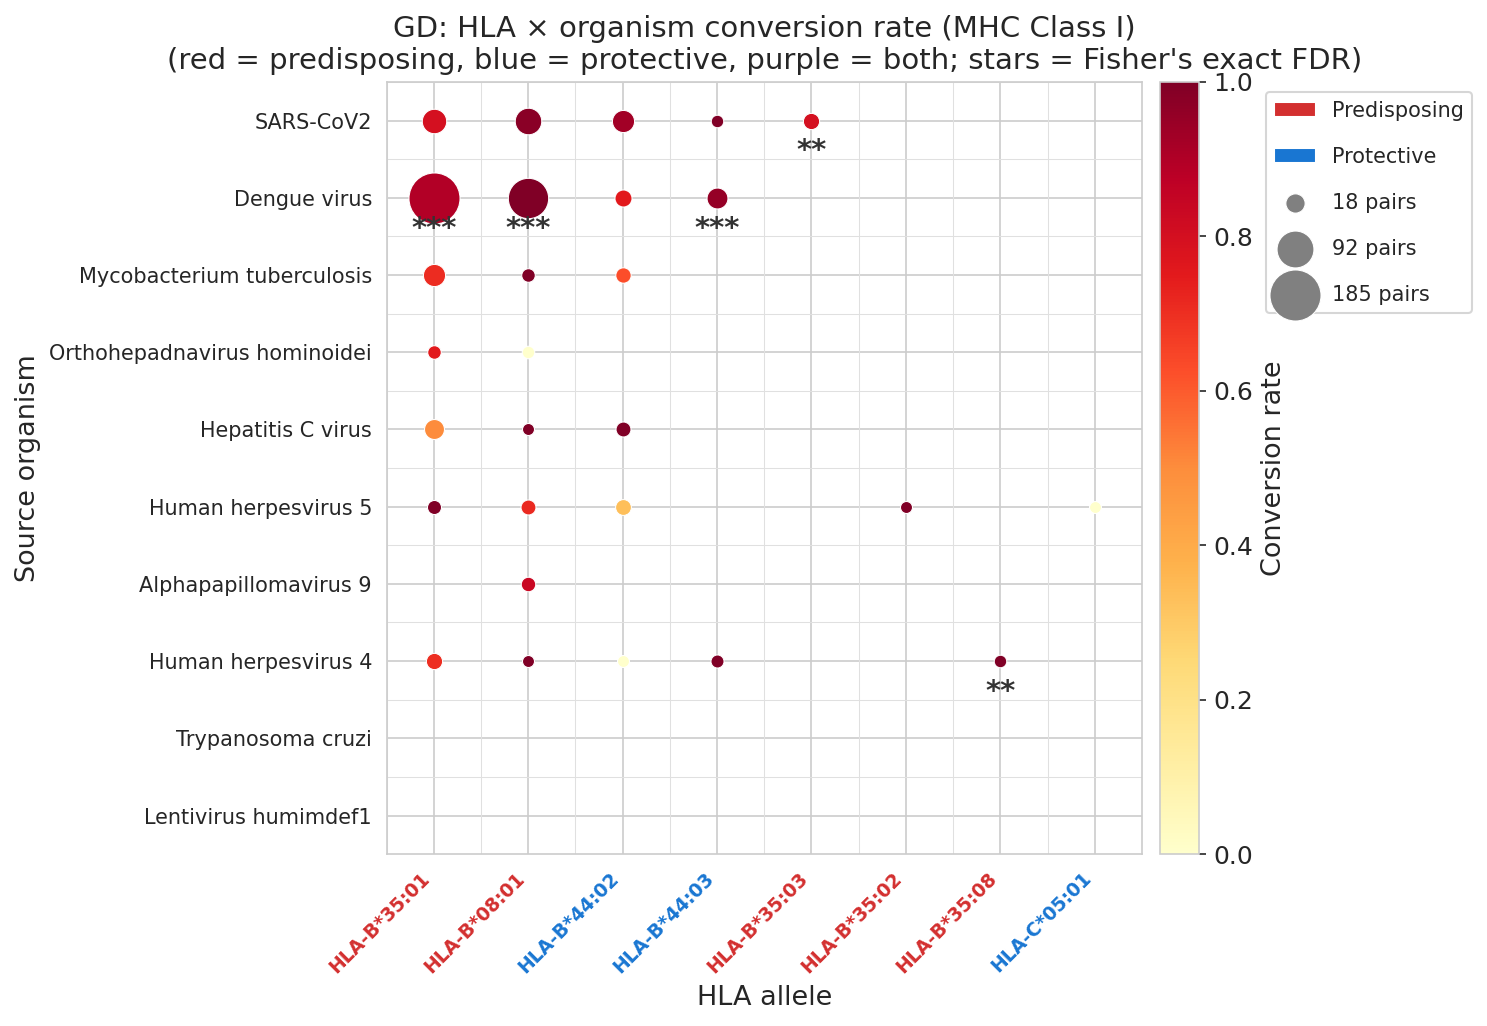

  ✅ 05b_GD_hla_organism_dotplot.png


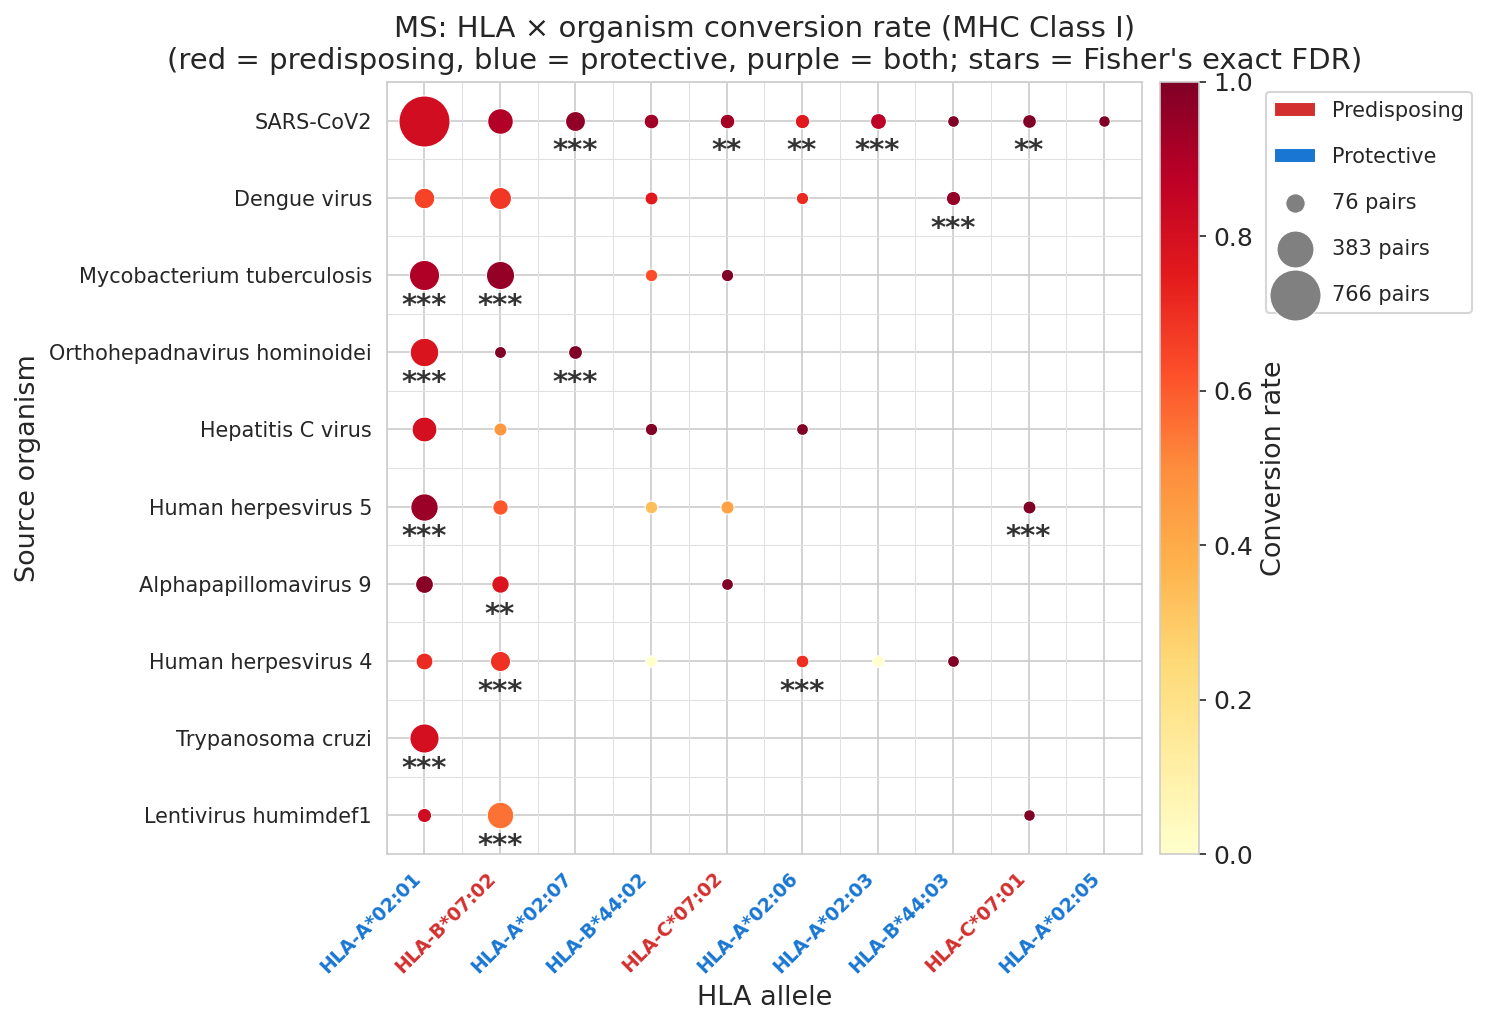

  ✅ 05b_MS_hla_organism_dotplot.png


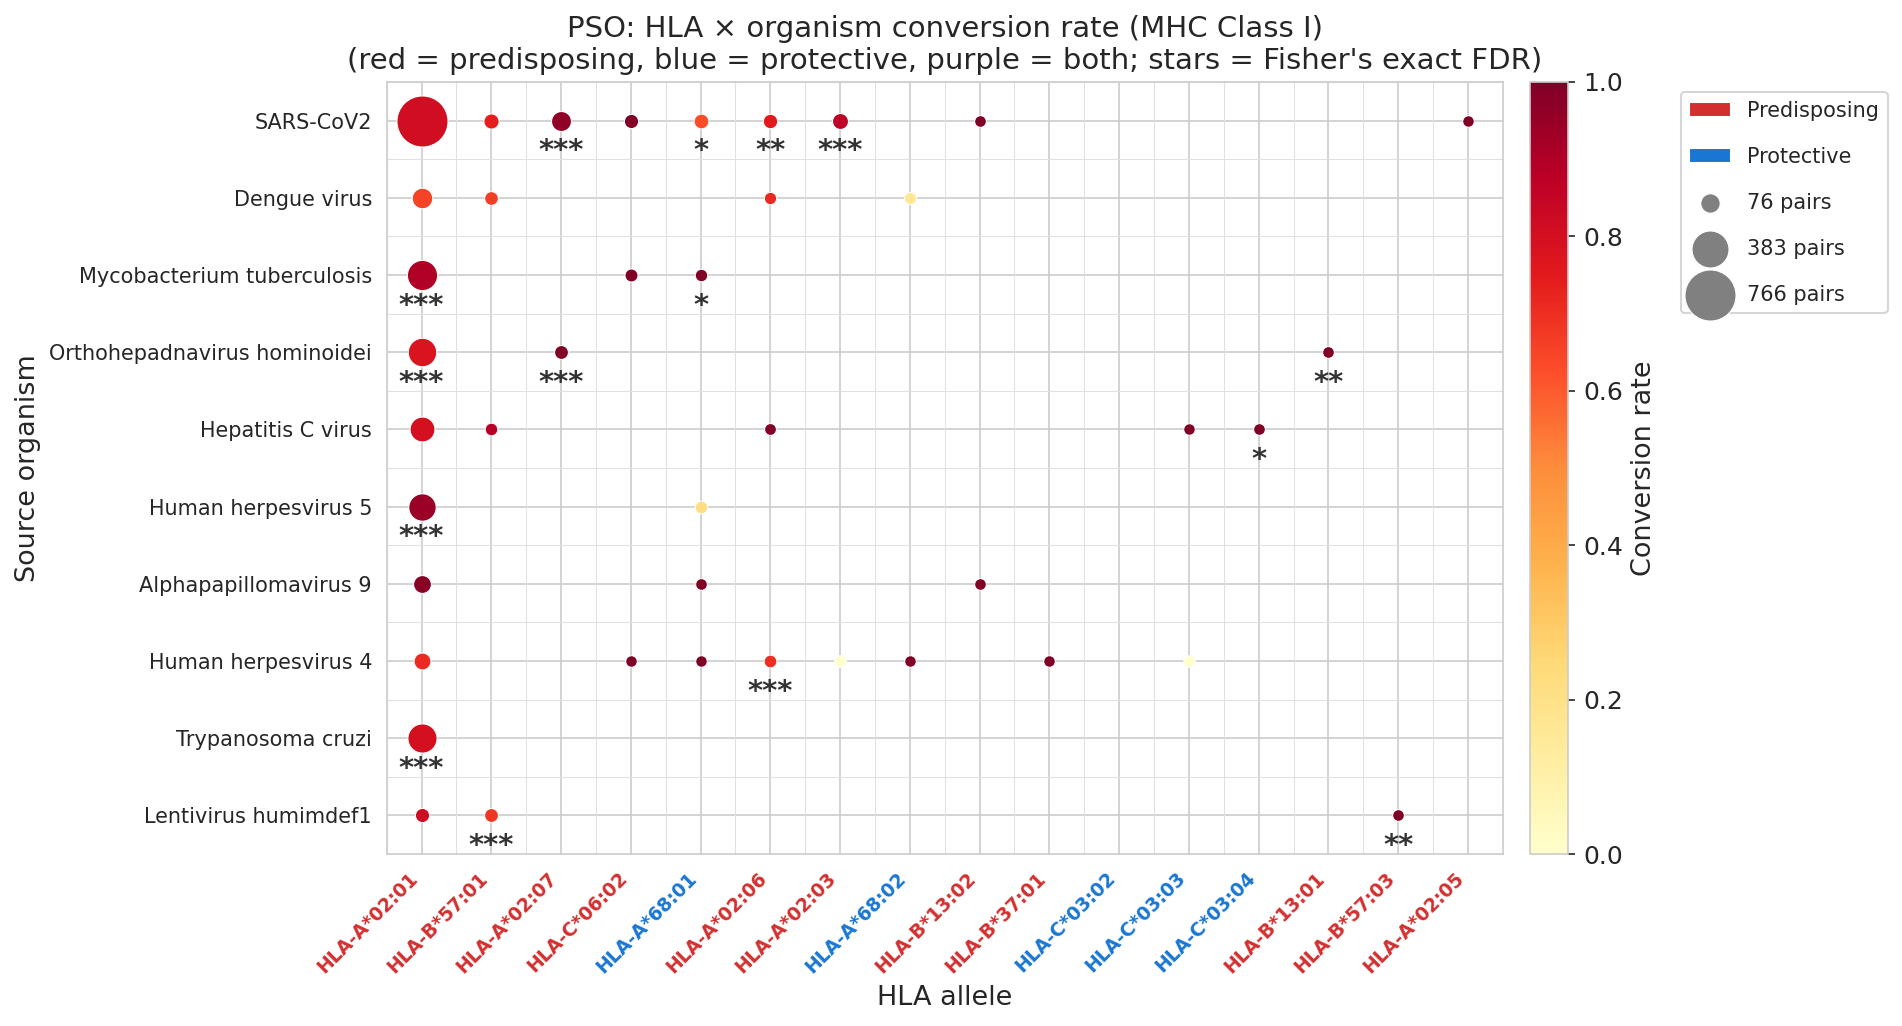

  ✅ 05b_PSO_hla_organism_dotplot.png


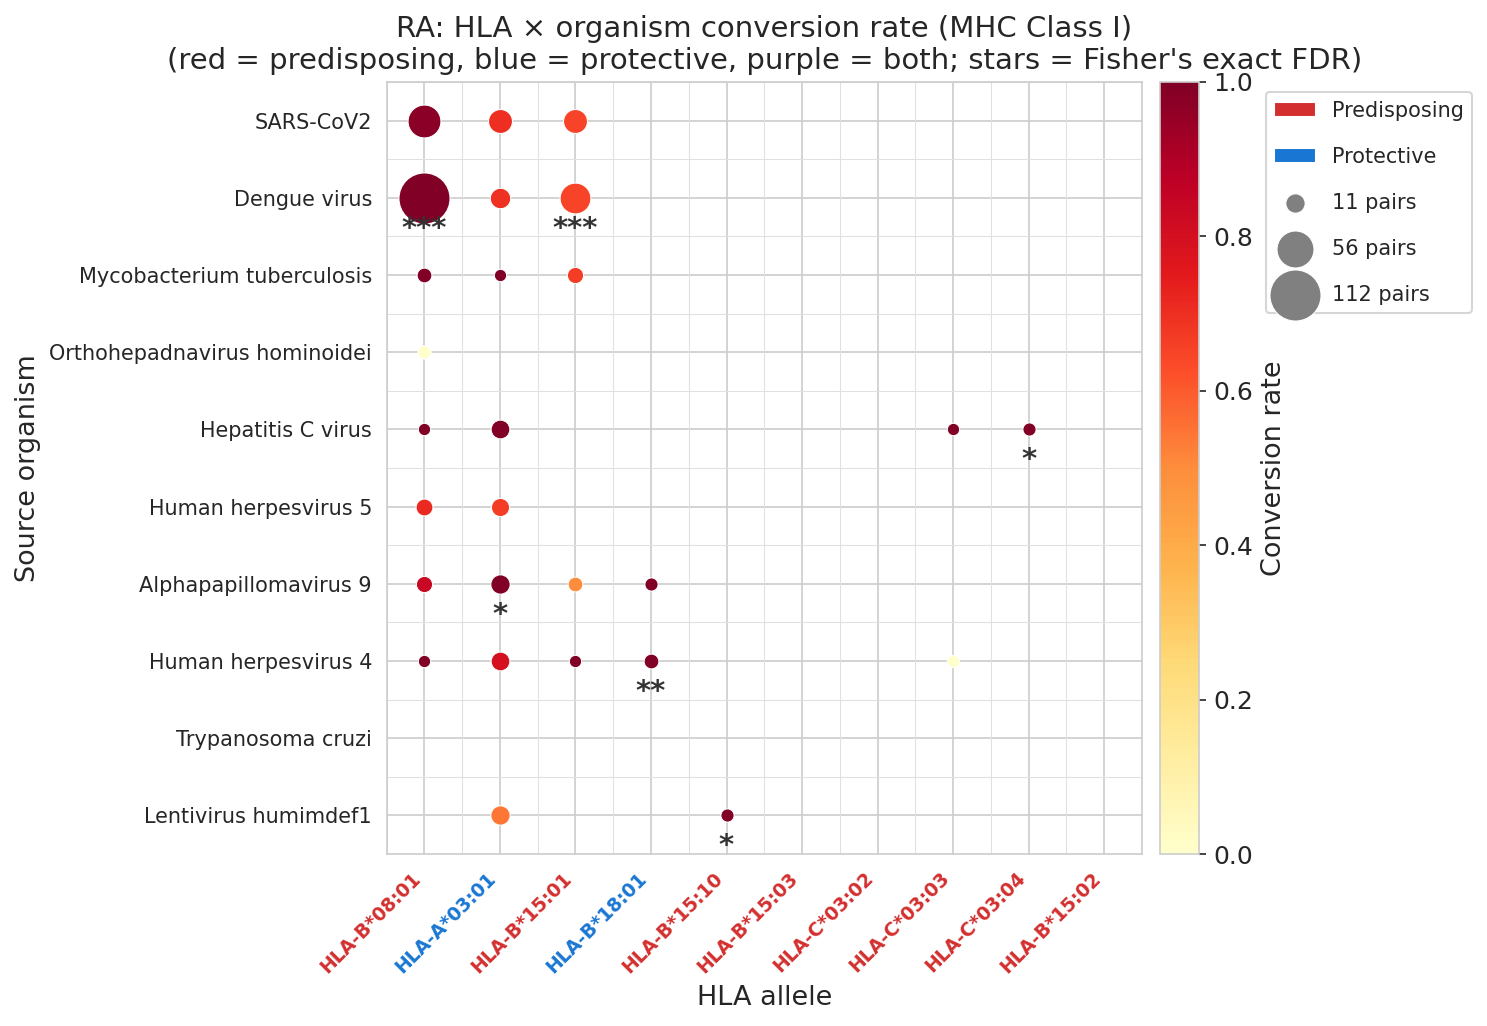

  ✅ 05b_RA_hla_organism_dotplot.png


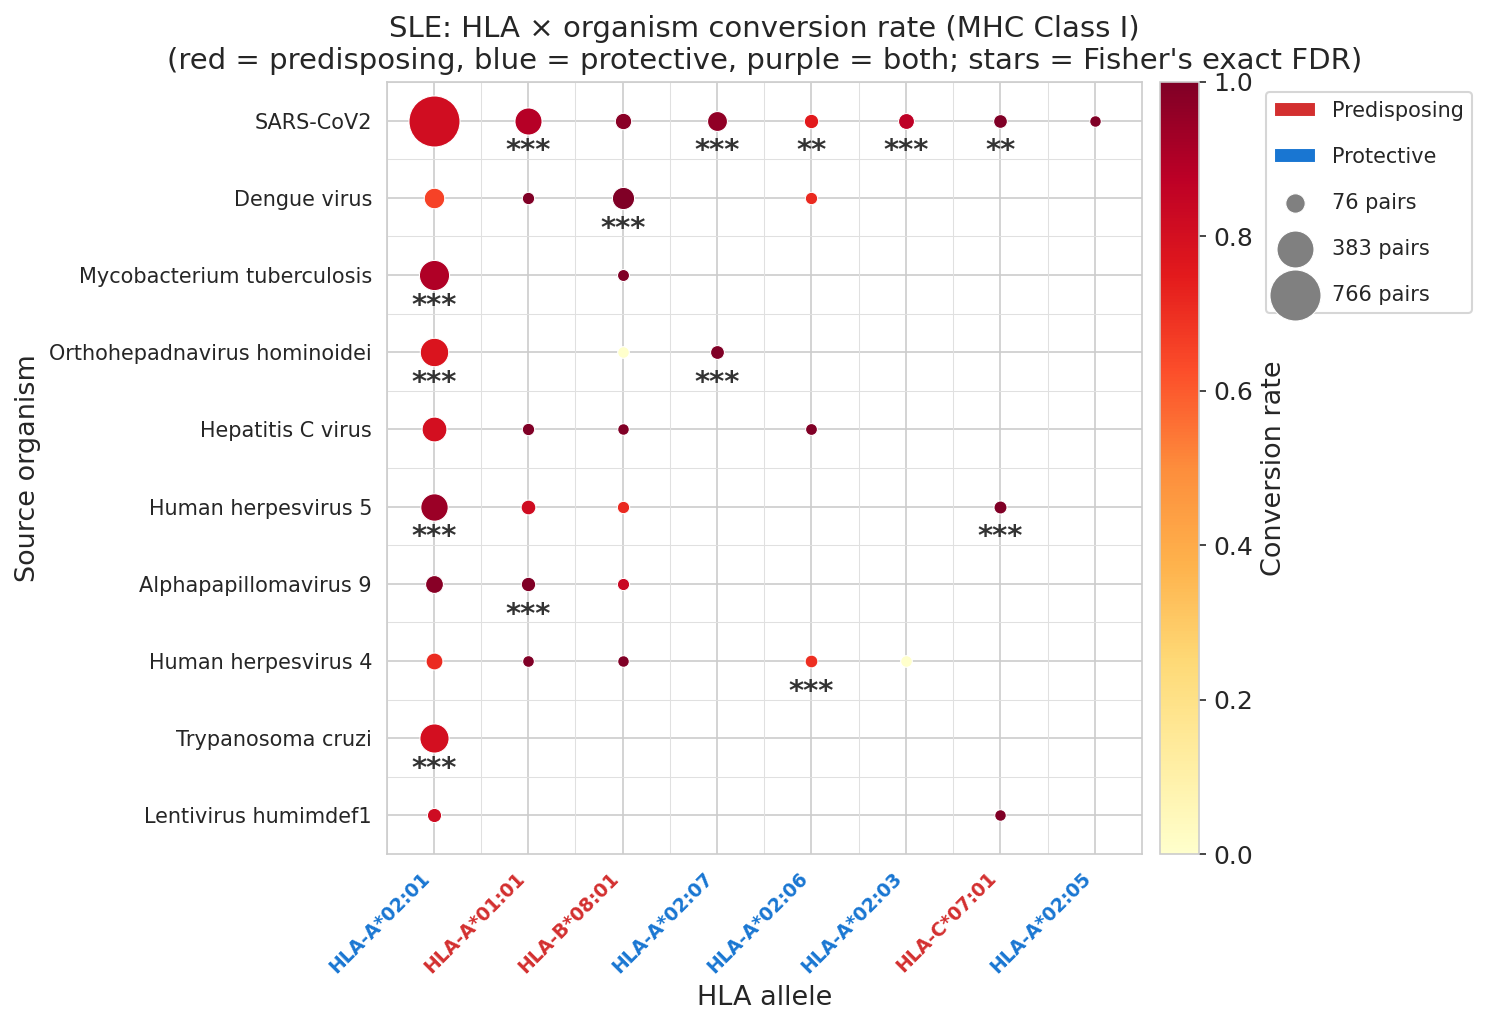

  ✅ 05b_SLE_hla_organism_dotplot.png


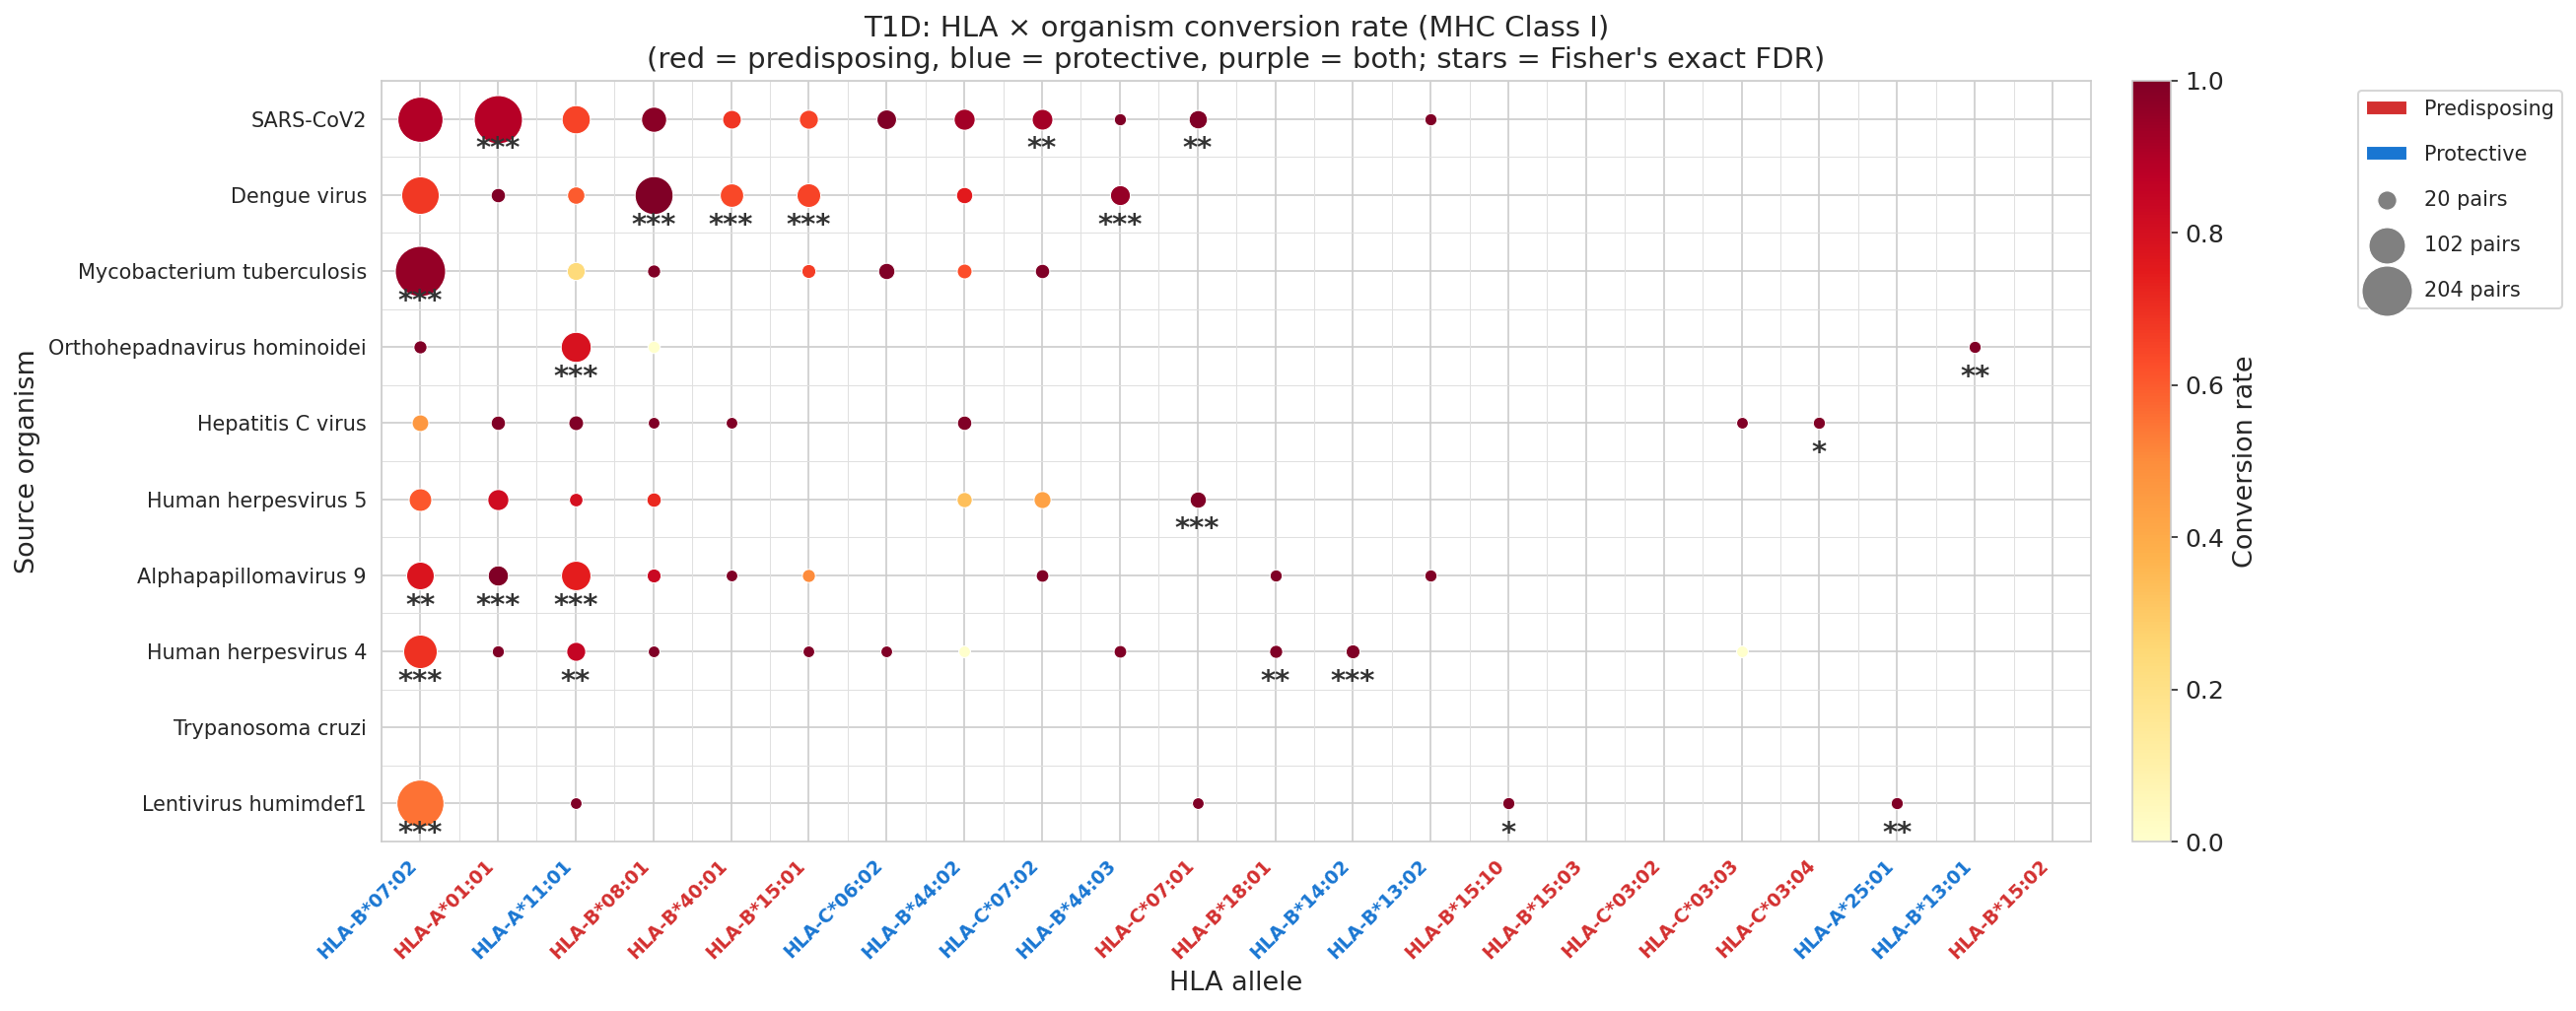

  ✅ 05b_T1D_hla_organism_dotplot.png


In [47]:
# %% Cell 16: Figure 5b — Per-disease HLA × Organism dot plots
print("Plotting per-disease HLA × organism dot plots (Figure 5b)...")

# Only plot diseases that have at least some alleles present in data
diseases_to_plot = []
for disease in all_diseases:
    pred_set = disease_pred.get(disease, set())
    prot_set = disease_prot.get(disease, set())
    # Check if any alleles from this disease appear in our data
    has_alleles = any(
        allele_matches_hla(a, pred_set | prot_set)
        for a in hla_conversion.index
        if hla_conversion.loc[a, "strong_pairs"] > 0
    )
    if has_alleles:
        diseases_to_plot.append(disease)

print(f"  Diseases with alleles in data: {len(diseases_to_plot)}")

for disease in diseases_to_plot:
    pred_set = disease_pred.get(disease, set())
    prot_set = disease_prot.get(disease, set())

    # Find alleles in data that are annotated for this disease
    disease_alleles_in_data = sorted(
        [a for a in hla_conversion.index
         if allele_matches_hla(a, pred_set | prot_set)
         and hla_conversion.loc[a, "strong_pairs"] > 0],
        key=lambda a: hla_conversion.loc[a, "input_pairs"], reverse=True,
    )

    if not disease_alleles_in_data:
        continue

    # Classify each allele for THIS disease
    allele_role = {}
    for a in disease_alleles_in_data:
        is_pred = allele_matches_hla(a, pred_set)
        is_prot = allele_matches_hla(a, prot_set)
        if is_pred:
            allele_role[a] = "Predisposing"
        elif is_prot:
            allele_role[a] = "Protective"

    # Build dot plot data
    d_frac = pd.DataFrame(np.nan, index=top_orgs_short, columns=disease_alleles_in_data)
    d_input = pd.DataFrame(0, index=top_orgs_short, columns=disease_alleles_in_data)
    d_stars = pd.DataFrame("", index=top_orgs_short, columns=disease_alleles_in_data, dtype=str)

    for org_full, org_short in zip(top_orgs_full, top_orgs_short):
        for allele in disease_alleles_in_data:
            key = (allele, org_full)
            if key in conversion.index:
                row = conversion.loc[key]
                d_frac.loc[org_short, allele] = row["fraction"]
                d_input.loc[org_short, allele] = int(row["input_pairs"])
                d_stars.loc[org_short, allele] = row["stars_interaction"]

    d_frac = d_frac.fillna(0)

    n_alleles = len(disease_alleles_in_data)
    fig, ax = plt.subplots(figsize=(max(10, n_alleles * 0.8), 7))
    vmax_d = max(min(d_frac.max().max() * 1.1, 1.0), 0.01)
    norm_d = plt.Normalize(vmin=0, vmax=vmax_d)
    max_input_d = max(d_input.max().max(), 1)

    for i, org_short in enumerate(top_orgs_short):
        for j, allele in enumerate(disease_alleles_in_data):
            frac = d_frac.loc[org_short, allele]
            n_input = d_input.loc[org_short, allele]
            if n_input == 0:
                continue
            dot_size = min_dot + (n_input / max_input_d) * (max_dot - min_dot)
            ax.scatter(j + 0.5, i + 0.5, s=dot_size, c=[cmap(norm_d(frac))],
                       edgecolors="white", linewidths=0.5, zorder=3)
            stars = d_stars.loc[org_short, allele]
            if stars:
                ax.text(j + 0.5, i + 0.9, stars, ha="center", va="center",
                        fontsize=14, fontweight="bold", color="#333", zorder=4)

    for i in range(len(top_orgs_short) + 1):
        ax.axhline(i, color="#E0E0E0", linewidth=0.5, zorder=1)
    for j in range(n_alleles + 1):
        ax.axvline(j, color="#E0E0E0", linewidth=0.5, zorder=1)

    ax.set_xlim(0, n_alleles)
    ax.set_ylim(0, len(top_orgs_short))
    ax.set_xticks([j + 0.5 for j in range(n_alleles)])
    ax.set_xticklabels(disease_alleles_in_data, rotation=45, ha="right", fontsize=9)
    ax.set_yticks([i + 0.5 for i in range(len(top_orgs_short))])
    ax.set_yticklabels(top_orgs_short, fontsize=10)
    ax.invert_yaxis()

    # Color allele labels by their role in THIS disease
    role_colors = {"Predisposing": "#D32F2F", "Protective": "#1976D2"}
    for label in ax.get_xticklabels():
        a = label.get_text()
        role = allele_role.get(a, "")
        if role in role_colors:
            label.set_color(role_colors[role])
            label.set_fontweight("bold")

    ax.set_xlabel("HLA allele")
    ax.set_ylabel("Source organism")
    ax.set_title(f"{disease}: HLA × organism conversion rate (MHC Class {MHC_CLASS})\n"
                 "(red = predisposing, blue = protective, purple = both; "
                 "stars = Fisher's exact FDR)")

    sm_d = plt.cm.ScalarMappable(cmap=cmap, norm=norm_d)
    sm_d.set_array([])
    cbar_d = plt.colorbar(sm_d, ax=ax, pad=0.02)
    cbar_d.set_label("Conversion rate")

    legend_elements_d = [
        Patch(facecolor="#D32F2F", label="Predisposing"),
        Patch(facecolor="#1976D2", label="Protective")
    ]
    legend_sizes_d = sorted(set(max(1, s) for s in [
        int(max_input_d * 0.1), int(max_input_d * 0.5), int(max_input_d)
    ]))
    legend_dots_d = [
        ax.scatter([], [], s=min_dot + (s / max_input_d) * (max_dot - min_dot),
                   c="gray", edgecolors="white", linewidths=0.5, label=f"{s:,} pairs")
        for s in legend_sizes_d
    ]
    all_handles = legend_elements_d + legend_dots_d
    ax.legend(handles=all_handles, loc="upper left",
              bbox_to_anchor=(1.15, 1.0), labelspacing=1.25,
              fontsize=10, frameon=True)

    plt.tight_layout()
    safe_disease = disease.replace(" ", "_").replace("/", "_")
    figpath = os.path.join(FIG_DIR, f"05b_{safe_disease}_hla_organism_dotplot.png")
    plt.savefig(figpath)
    plt.show()
    print(f"  ✅ {os.path.basename(figpath)}")
